# TCs 
### Logically merging TAs
#### There's two ways we could do this:
####  1. using some  clustering algorithm in 3D. 
####  2. using simplified nearest neighbour operations checks. 
### in principle   both of these would require some logical coordinate system. Ultimately the question is - what information do we want the TCs to encode

In [211]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import trigger_algs_numba as trg_numba
import utils as util
import uproot
import glob
import os

cc='orangered'; cl = 'steelblue'

#TAMaker parameters settings based on backgrounds - central config is default, lateral APAs require higher auto accept window threshold + cluster req. due to higher proportion of externals 
lat_params = { "accept_threshold": 130e3, "cluster_cut": 30e3 }



def load_data(filepath, tree_key):
    try:
        with uproot.open(filepath) as file:
            tree = file[tree_key]
            return tree.arrays(library='pd')
    except Exception as e:
        print(f"Error loading data from {filepath}: {e}")
        return None

def load_all_data(folder, tree_key):
    all_files = glob.glob(os.path.join(folder, "*.root"))
    dfs = [load_data(f, tree_key) for f in all_files]
    dfs = [df for df in dfs if df is not None]
    
    if not dfs:
        return None
    
    full_df = pd.concat(dfs, ignore_index=True)
    util.get_unique_event_ids(full_df)
    
    return full_df.sort_values(by="event_uid")



def load_all_tp_data(folder, tree_key):
    all_files = glob.glob(os.path.join(folder, "*.root"))
    dfs = []

    for f in all_files:
        df = load_data(f, tree_key)
        if df is None:
            continue

        mask = ( (df["samples_over_threshold"] > 8) &(df["readout_view"] == 2) &(df["adc_peak"] > 80))

        df_filtered = df[mask]

        if not df_filtered.empty:
            dfs.append(df_filtered)

    if not dfs:
        return None

    full_df = pd.concat(dfs, ignore_index=True) 
    util.get_unique_event_ids(full_df)

    return full_df.sort_values(by="event_uid")

cosmic_mc= pd.read_pickle("./cosmics/pkl/cosmic_mc_001.pkl")
cosmic_tps= pd.read_pickle("./cosmics/pkl/cosmic_tps_001.pkl")
cosmic_evsum = pd.read_pickle("./cosmics/pkl/cosmic_eventsum_001.pkl")
cosmic_mcparts = pd.read_pickle("./cosmics/pkl/cosmic_mcparticles_001.pkl") 


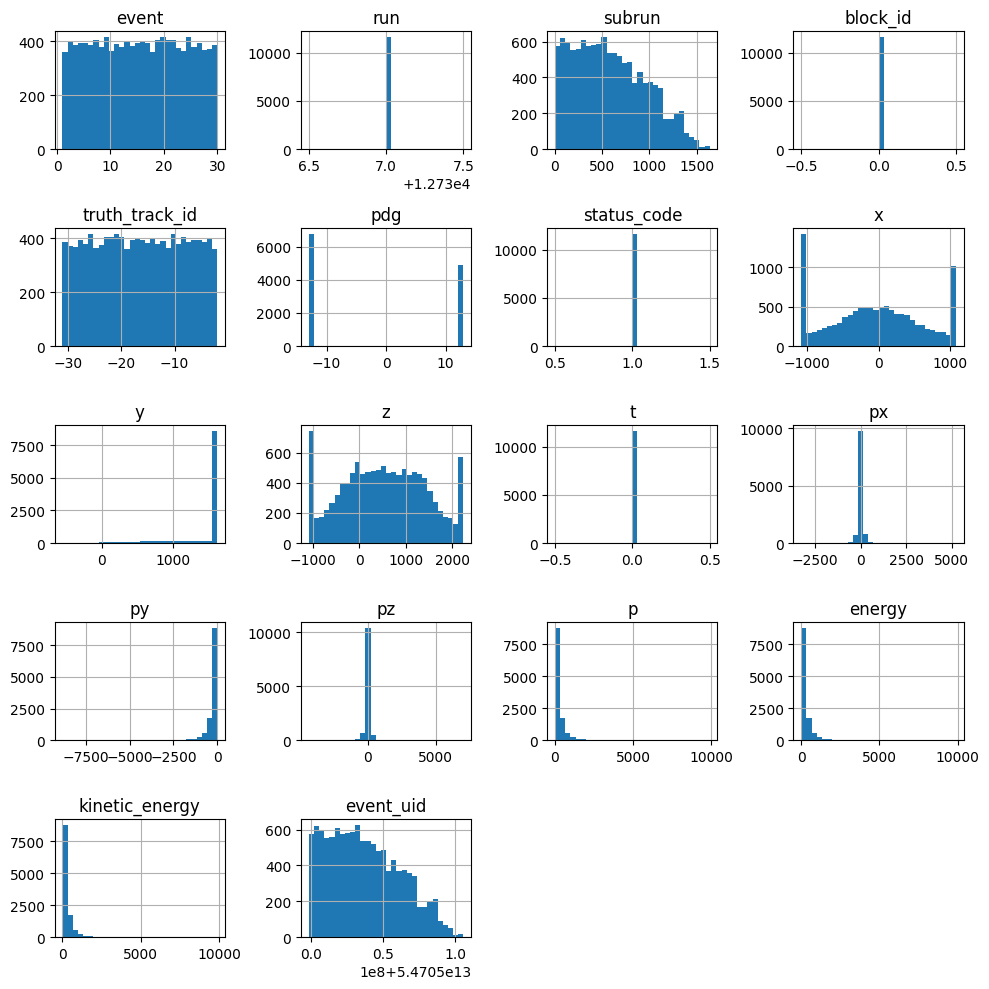

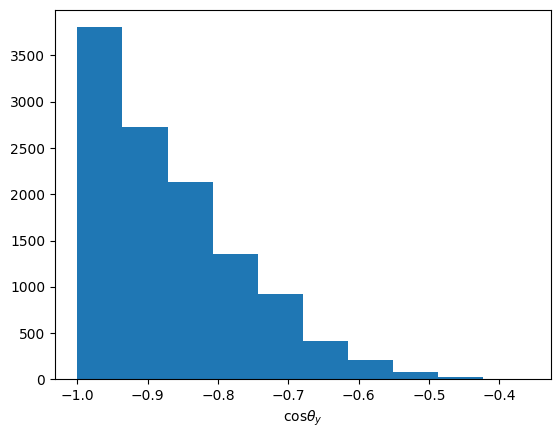

In [2]:
cosmic_mc.hist(bins =30, figsize= (10,10))
plt.tight_layout()
plt.show()


plt.hist(cosmic_mc.py/cosmic_mc.p)
plt.xlabel(r"cos$\theta_y$")
plt.show()

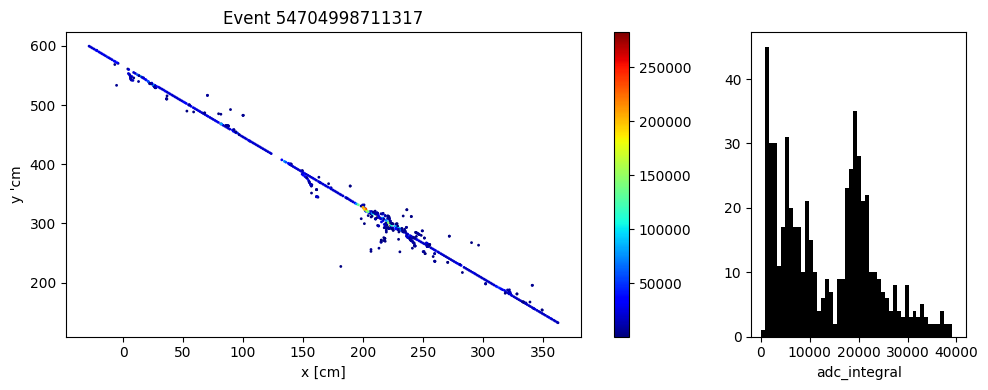

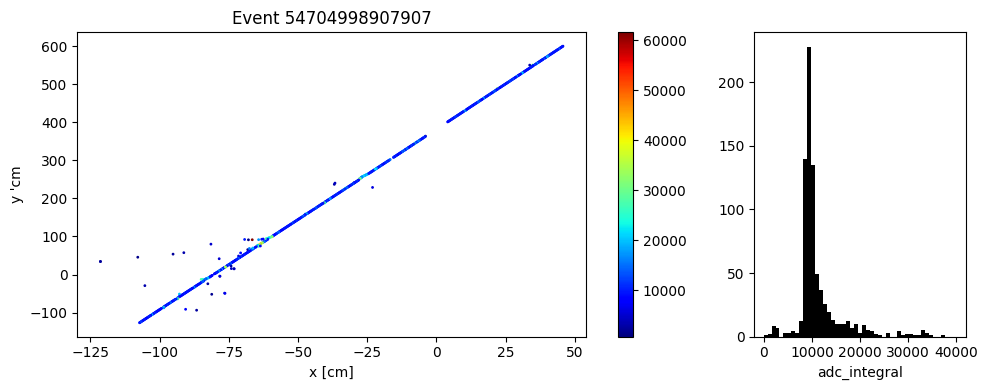

In [212]:
import matplotlib.pyplot as plt
import numpy as np

for i in [18, 28]:
    ev = cosmic_tps.event_uid.unique()[i]
    x = cosmic_tps[(cosmic_tps.event_uid == ev) & (cosmic_tps.bt_edep > 0)]

    fig, axs = plt.subplots(1, 2, figsize=(10, 4), gridspec_kw={'width_ratios': [3, 1]})
    axs[0].scatter(x.bt_x, x.bt_y, c=x.adc_integral, s=1, cmap='jet')
    axs[0].set_title(f"Event {ev}")
    axs[0].set_xlabel("x [cm]")
    axs[0].set_ylabel("y 'cm")
    fig.colorbar(axs[0].collections[0], ax=axs[0])

    axs[1].hist(x.adc_integral, bins=np.linspace(0, 40e3, 50), color='k')
    axs[1].set_xlabel("adc_integral")

    plt.tight_layout()
    plt.show()


In [213]:
#Map the TPC IDs to a 3D logical grid to be able to extract nearest neighbours within the TC using straight forward functions?? 
# Maps TPC id -> (ix, iy, iz)
TPC_ID_TO_INDEX = {
    0: (0, 0, 0),  1: (1, 0, 0),
    2: (0, 1, 0),  3: (1, 1, 0),
    4: (0, 0, 1),  5: (1, 0, 1),
    6: (0, 1, 1),  7: (1, 1, 1),
    8: (0, 0, 2),  9: (1, 0, 2),
   10: (0, 1, 2), 11: (1, 1, 2),
   12: (0, 0, 3), 13: (1, 0, 3),
   14: (0, 1, 3), 15: (1, 1, 3),
   16: (0, 0, 4), 17: (1, 0, 4),
   18: (0, 1, 4), 19: (1, 1, 4),
   20: (0, 0, 5), 21: (1, 0, 5),
   22: (0, 1, 5), 23: (1, 1, 5)
}

# Invert it if needed:
INDEX_TO_TPC_ID = {v: k for k, v in TPC_ID_TO_INDEX.items()}

cosmic_tps['original_event'] = cosmic_tps.event
cosmic_tps['event'] = cosmic_tps.event_uid

# make cosmic TAs: 
print("\n" + f"generating central APA efficiencies for cosmics")
cTPs_cosmic, cTAs_cosmic  = util.GenerateTAs(cosmic_tps)
print("\n" + f"generating lateral APA efficiencies for cosmics")
lTPs_cosmic, lTAs_cosmic  = util.GenerateTAs(cosmic_tps, **lat_params)

cTAs_cosmic['event_uid'] = cTAs_cosmic['event']
lTAs_cosmic['event_uid'] = lTAs_cosmic['event']

cTAs_cosmic["voxel"] = cTAs_cosmic["tpc"].map(TPC_ID_TO_INDEX)
lTAs_cosmic["voxel"] = lTAs_cosmic["tpc"].map(TPC_ID_TO_INDEX)

cosmic_evsum['visible_energy'] = cosmic_evsum.tot_visible_energy_rop2 + cosmic_evsum.tot_visible_energy_rop3 
trig_cosmic_cent =  pd.merge(cTAs_cosmic, cosmic_evsum[[ 'visible_energy', 'event_uid']], on=['event_uid'], how='right').fillna(-1)
trig_cosmic_lat =  pd.merge(lTAs_cosmic, cosmic_evsum[[ 'visible_energy', 'event_uid']], on=['event_uid'], how='right').fillna(-1)



display(trig_cosmic_cent)


generating central APA efficiencies for cosmics
Processing run 1/1


100%|██████████| 1786/1786 [00:00<00:00, 9561.22it/s]



generating lateral APA efficiencies for cosmics
Processing run 1/1


100%|██████████| 2693/2693 [00:00<00:00, 15807.34it/s]


,event,apa_id,tpc,rop,window_start,flag,TA_id,total_window_energy,TP_count,n_clusters,...,ch_std,t_std,ch_wmean,t_wmean,ch_wstd,t_wstd,run,event_uid,voxel,visible_energy
0,-1.000000e+00,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,...,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.0,54704998514690,-1,0.000000
1,-1.000000e+00,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,...,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.0,54704998514691,-1,0.000000
2,5.470500e+13,8.0,16.0,2.0,1000.0,2.0,3.0,2547704.0,57.0,-1.0,...,34.594205,211.479400,22194.920431,1638.055396,11.651623,224.193669,12737.0,54704998514692,"(0, 0, 4)",7617.002653
3,5.470500e+13,8.0,16.0,2.0,2000.0,2.0,4.0,21771877.0,393.0,-1.0,...,26.456593,210.238533,22177.761849,2380.018631,9.704395,156.063325,12737.0,54704998514692,"(0, 0, 4)",7617.002653
4,5.470500e+13,8.0,16.0,2.0,3000.0,2.0,5.0,1574396.0,37.0,-1.0,...,32.640974,104.976550,22163.383820,3213.382814,8.199116,98.558274,12737.0,54704998514692,"(0, 0, 4)",7617.002653
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30660,-1.000000e+00,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,...,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.0,54705105731595,-1,0.000000
30661,-1.000000e+00,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,...,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.0,54705105731598,-1,0.000000
30662,-1.000000e+00,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,...,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.0,54705105731602,-1,0.000000
30663,-1.000000e+00,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,...,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.0,54705105731604,-1,0.000000


/var/folders/1s/mfxsnwp9275ft3r75z4zs6c80000gn/T/ipykernel_16694/1003634383.py:4: RuntimeWarning: overflow encountered in exp
  return L / (1 + np.exp(-k * (x - x0))) + b


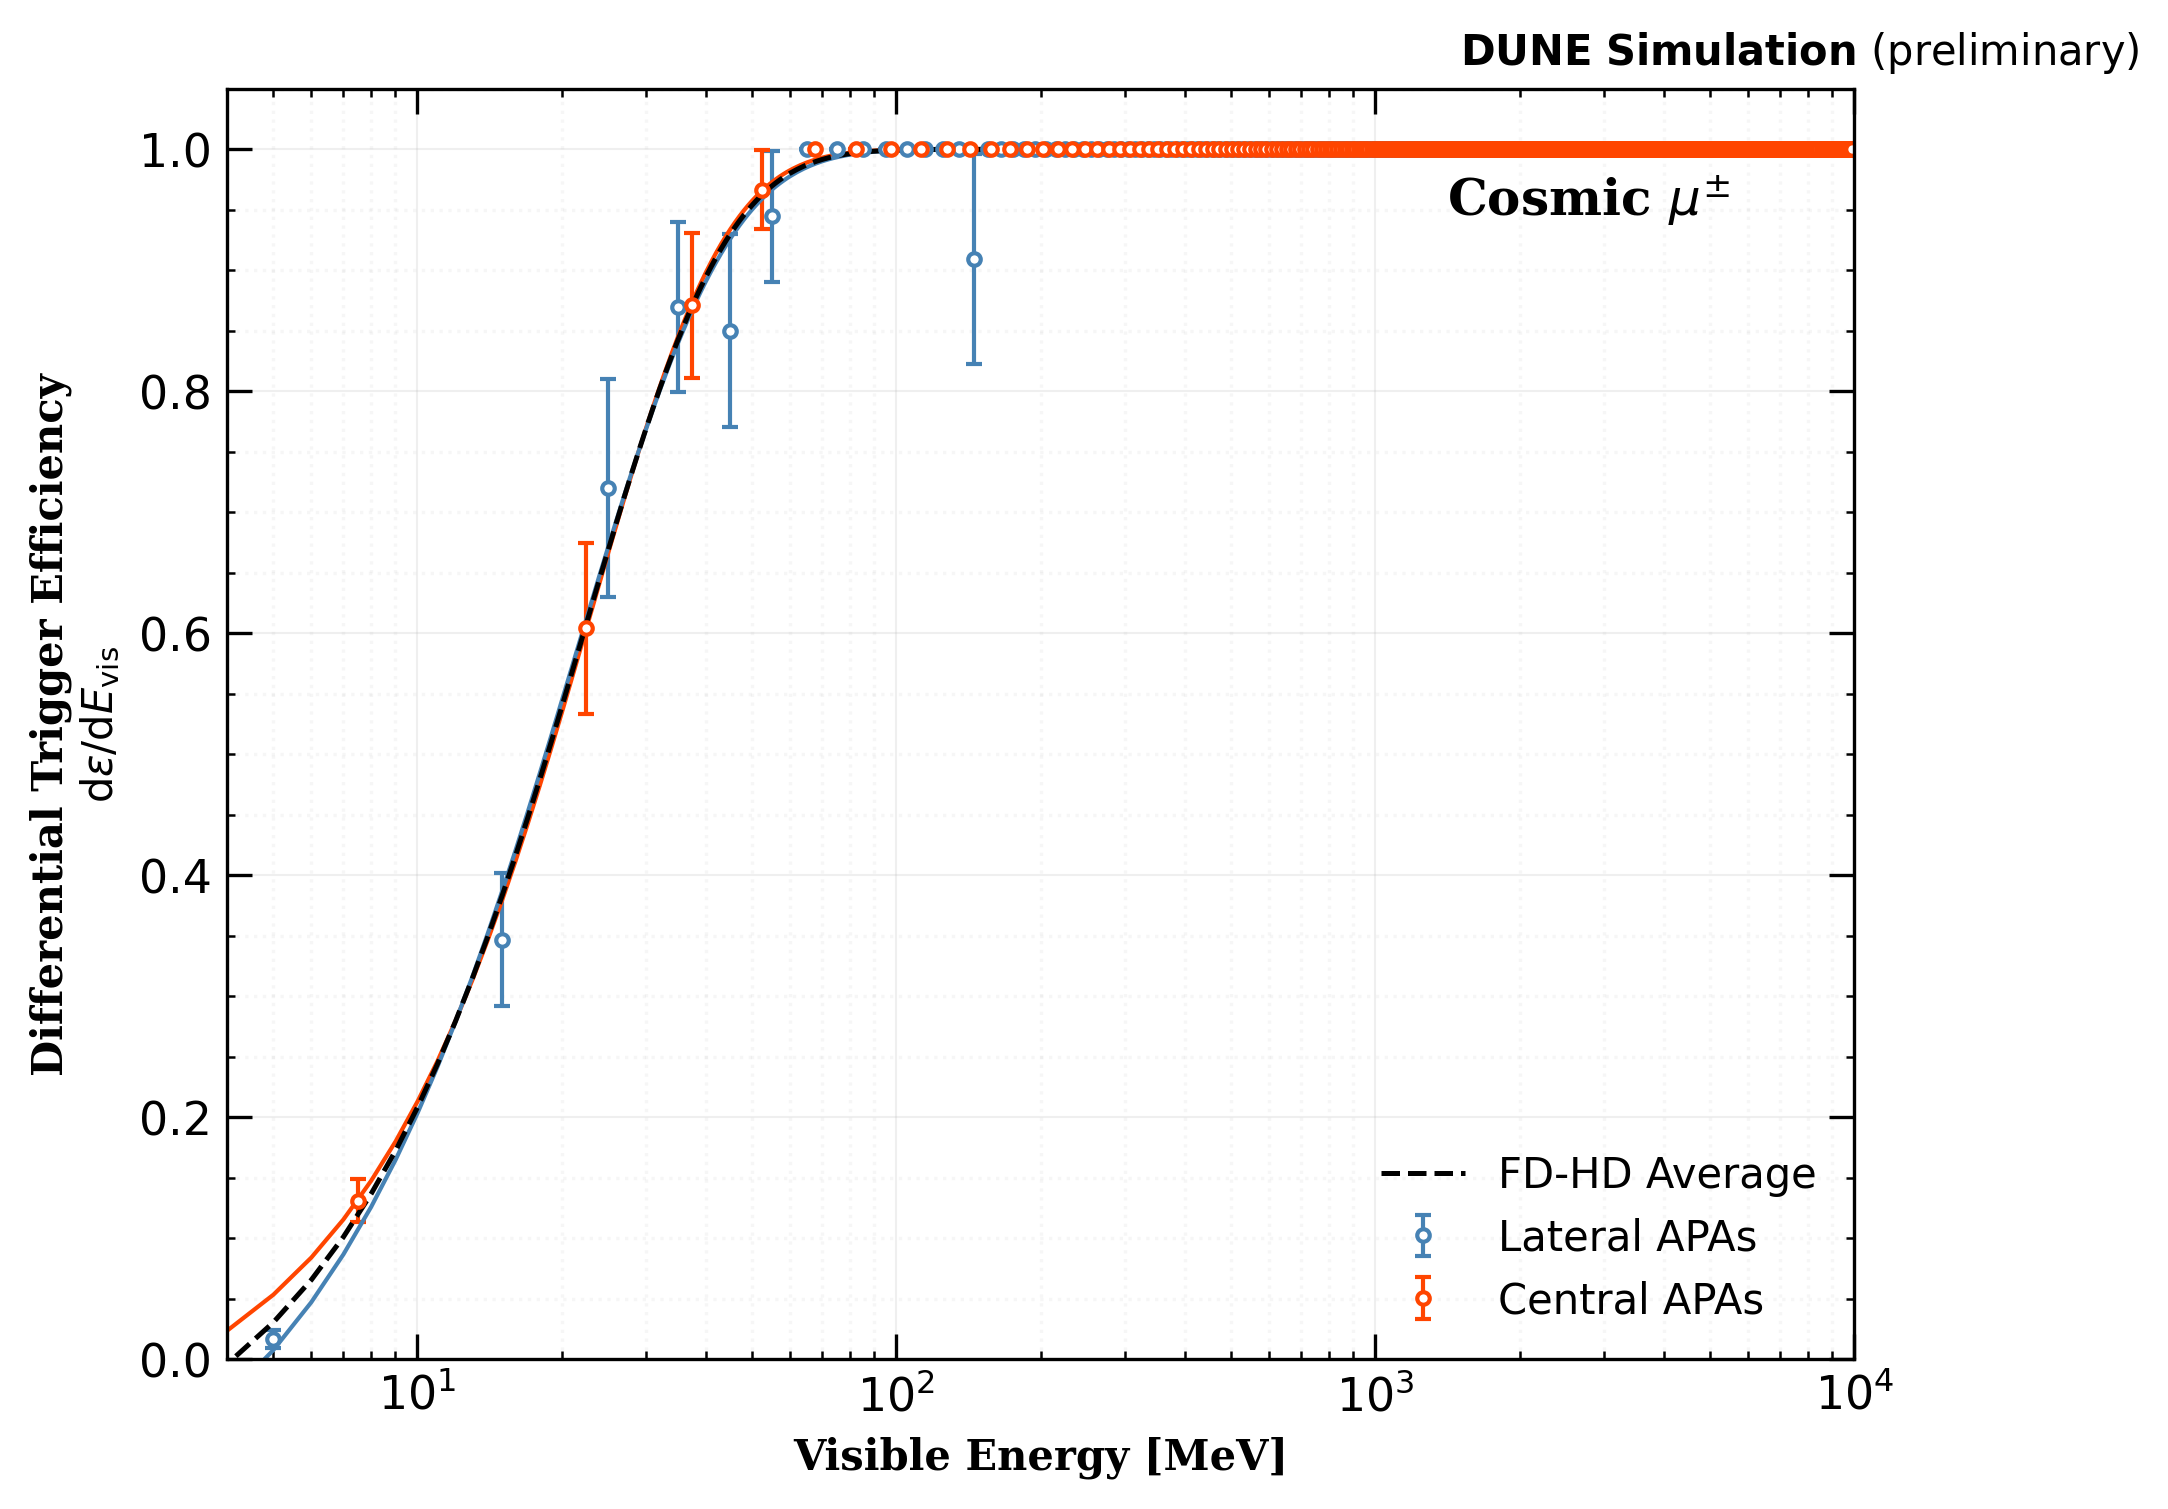

In [214]:
from scipy.optimize import curve_fit

def sigmoid(x, L, x0, k, b):
    return L / (1 + np.exp(-k * (x - x0))) + b

data_lat = [trig_cosmic_lat[trig_cosmic_lat.visible_energy> 1]]
data_cent = [trig_cosmic_cent[trig_cosmic_cent.visible_energy > 1]]
#fig, ax = plt.subplots(1, 1, figsize=(7, 5), dpi=200, sharex=True, sharey=True)
fig, ax = plt.subplots(figsize=(7,5.5), dpi=300)
lines_for_legend = []

for idx in range(len(data_lat)):
    dx_lat = 10
    dx_cent =15
    max_eng = 1e4

    energies_lat = np.arange(0, max_eng, dx_lat)
    bin_centers_lat = energies_lat[:-1] + dx_lat / 2

    energies_cent = np.arange(0, max_eng, dx_cent)
    bin_centers_cent = energies_cent[:-1] + dx_cent / 2

    sensitivity_lat = []
    errors_lat = []
    df_lat = data_lat[idx]
    for energy_start in energies_lat[:-1]:
        upper = energy_start + dx_lat
        events_in_bin = df_lat[(df_lat.visible_energy >= energy_start) & (df_lat.visible_energy < upper)]
        accepted_events_in_bin = events_in_bin[events_in_bin.flag == 2]

        n = events_in_bin.event_uid.nunique()
        k = accepted_events_in_bin.event_uid.nunique()

        if n > 0:
            sens = k / n
            err = np.sqrt(sens * (1 - sens) / n)
        else:
            sens = np.nan
            err = 0

        sensitivity_lat.append(sens)
        errors_lat.append(err)

    sensitivity_cent = []
    errors_cent = []
    df_cent = data_cent[idx]
    for energy_start in energies_cent[:-1]:
        upper = energy_start + dx_cent
        events_in_bin = df_cent[(df_cent.visible_energy >= energy_start) & (df_cent.visible_energy < upper)]
        accepted_events_in_bin = events_in_bin[events_in_bin.flag == 2]

        n = events_in_bin.event_uid.nunique()
        k = accepted_events_in_bin.event_uid.nunique()

        if n > 0:
            sens = k / n
            err = np.sqrt(sens * (1 - sens) / n)
        else:
            sens = np.nan
            err = 0

        sensitivity_cent.append(sens)
        errors_cent.append(err)

    bin_centers_lat = np.array(bin_centers_lat)
    sensitivity_lat = np.array(sensitivity_lat)
    errors_lat = np.array(errors_lat)

    bin_centers_cent = np.array(bin_centers_cent)
    sensitivity_cent = np.array(sensitivity_cent)
    errors_cent = np.array(errors_cent)

    mask_lat = ~np.isnan(sensitivity_lat)
    mask_cent = ~np.isnan(sensitivity_cent)

    try:
        popt_lat, _ = curve_fit(sigmoid, bin_centers_lat[mask_lat], sensitivity_lat[mask_lat], p0=[1, 10, 1, 0], maxfev=1000)
    except:
        popt_lat = [1, 10, 1, 0]
    try:
        popt_cent, _ = curve_fit(sigmoid, bin_centers_cent[mask_cent], sensitivity_cent[mask_cent], p0=[1, 10, 1, 0], maxfev=1000)
    except:
        popt_cent = [1, 10, 1, 0]

    x_fit = np.linspace(0, 1000, 1000)
    y_fit_lat = sigmoid(x_fit, *popt_lat)
    y_fit_cent = sigmoid(x_fit, *popt_cent)
    y_fit_mean = (y_fit_lat + y_fit_cent) / 2



    ax.errorbar(bin_centers_lat, sensitivity_lat, yerr=errors_lat, fmt='o', capsize=2, markersize=3,markerfacecolor='white', elinewidth=1, color=cl, label='Lateral APAs')
    ax.errorbar(bin_centers_cent, sensitivity_cent, yerr=errors_cent, fmt='o', capsize=2, markersize=3,markerfacecolor='white', elinewidth=1, color=cc, label = 'Central APAs')
    line_cent, = ax.plot(x_fit, y_fit_cent, color=cc, linewidth=1)
    line_lat, = ax.plot(x_fit, y_fit_lat, color=cl, linewidth=1)



    line_mean, = ax.plot(x_fit, y_fit_mean, color='black', linewidth=1.2, linestyle='--', label ="FD-HD Average")

    if idx == 0: lines_for_legend = [line_cent, line_lat, line_mean]

    ax.tick_params(axis='both', which='both', direction='in', top=True, right=True, labelsize=11)
    ax.set_ylim(0, 1.05)
    ax.set_xlim(0,1e5)
    ax.grid(True, which='major', linestyle='-', linewidth=0.5, alpha=0.2)
    ax.grid(True, which='minor', linestyle=':', alpha =0.1)
    ax.set_xscale('log')
    ax.set_xlim(4,max_eng)
    ax.set_xlabel("Visible Energy [MeV]", fontweight='bold', family='serif')
    ax.set_ylabel(r"Differential Trigger Efficiency" + "\n" + r"$\mathrm{d}\varepsilon / \mathrm{d}E_\mathrm{vis}$",  fontweight='bold',  family='serif')
    ax.legend( frameon=False, loc='lower right',  ncol=1)
    ax.tick_params(axis='both', which='both', direction='in', top=True, right=True)
    ax.tick_params(axis='both', which='major', direction='in', top=True, right=True, length =6)
    ax.text(1.5e3, 1.07, r'$\bf{DUNE\ Simulation}$ (preliminary)')
    ax.minorticks_on()
    ax.text(0.75, 0.90, r"Cosmic $\mu^{\pm}$", transform=ax.transAxes, fontsize=12, fontweight='bold', family='serif')
    ax.legend(loc = 'lower right', frameon = False)
plt.show()

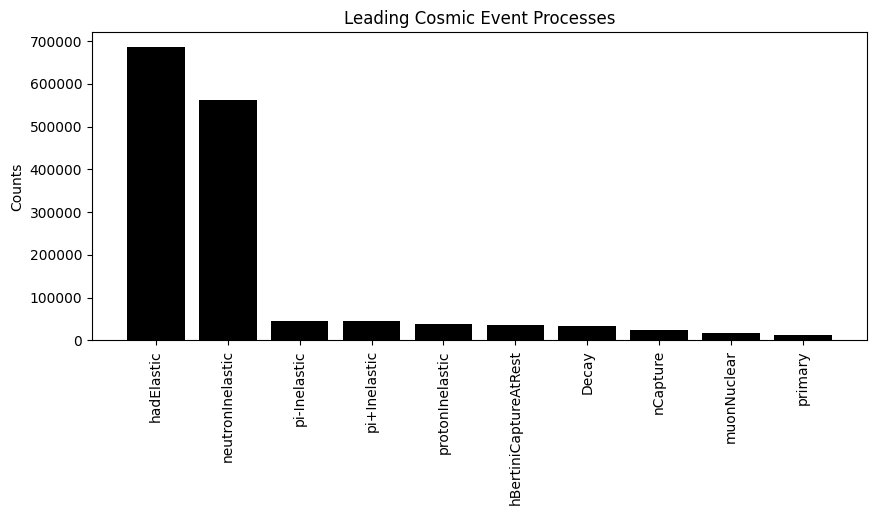

1000080160: 492434
22: 334847
2112: 180452
1000140280: 107420
2212: 87805
1000060120: 44459
1000130270: 31739
1000260560: 25343
1000180400: 23735
1000020040: 21823
11: 18446
1000120240: 15798
13: 14476
211: 14206
1000200400: 9145
1000010020: 7791
14: 7646
1000140290: 7181
111: 6768
1000160320: 6648
1000070150: 6180
1000120260: 4763
12: 4375
1000110230: 4324
1000070140: 4185


In [215]:

processes, counts = np.unique(cosmic_mcparts.process, return_counts=True)
leading_processes = sorted(zip(processes, counts), key=lambda x: x[1], reverse=True)[:10]
processes_leading, counts_leading = zip(*leading_processes)

plt.figure(figsize=(10,4))
plt.bar(processes_leading, counts_leading, color='k')
plt.xticks(rotation=90)
plt.ylabel('Counts')
plt.title('Leading Cosmic Event Processes')
plt.show()


leading_parts = sorted(zip(*np.unique(np.abs(cosmic_mcparts.pdg), return_counts=True)), key=lambda x: x[1], reverse=True)[:25]
for pdg, count in leading_parts: print(f"{pdg}: {count}")




,event,run,subrun,pdg,generator_name,status_code,g4_track_id,mother,truth_block_id,x,...,py,pz,energy,kinetic_energy,edep,numelectrons,shower_edep,shower_numelectrons,process,event_uid
1334380,18,12737,35,1000080160,largeant,1,4312,1,0,11.798960,...,0.028406,0.048375,14.895189,0.000107,0.0,0.0,0.0,0.0,hadElastic,54705000742930
1334381,18,12737,35,1000080160,largeant,1,4313,1,0,11.872142,...,-0.015543,-0.048644,14.895172,0.000090,0.0,0.0,0.0,0.0,hadElastic,54705000742930
1334379,18,12737,35,1000080160,largeant,1,4311,1,0,16.040595,...,0.028472,-0.034566,14.895156,0.000074,0.0,0.0,0.0,0.0,hadElastic,54705000742930
1334375,18,12737,35,13,largeant,1,1,0,0,432.559923,...,-278.181864,257.244408,379.975876,379.870217,0.0,0.0,0.0,0.0,primary,54705000742930
1334377,18,12737,35,1000130270,largeant,1,4309,1,0,16.320317,...,0.010758,0.018760,25.126584,0.000078,0.0,0.0,0.0,0.0,hadElastic,54705000742930
1334376,18,12737,35,1000080160,largeant,1,4308,1,0,21.558058,...,0.015789,0.046172,14.895208,0.000127,0.0,0.0,0.0,0.0,hadElastic,54705000742930
1334378,18,12737,35,1000080160,largeant,1,4310,1,0,18.719173,...,-0.060979,0.004496,14.895209,0.000128,0.0,0.0,0.0,0.0,hadElastic,54705000742930


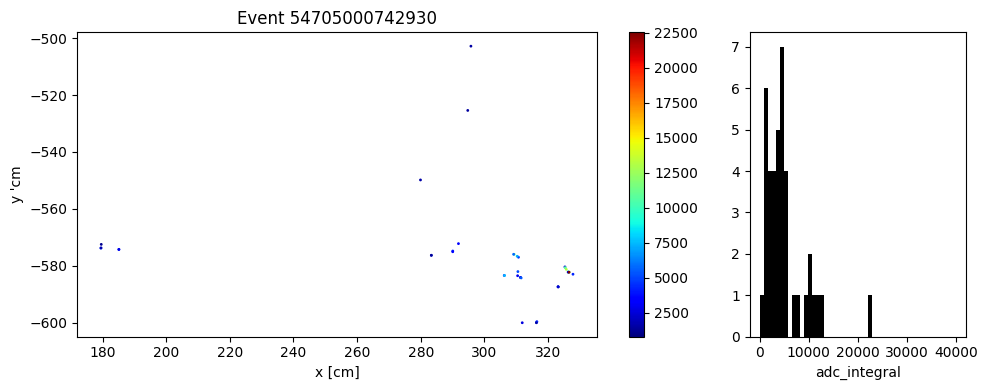

In [216]:
ev = 54705000742930

display(cosmic_mcparts[cosmic_mcparts.event_uid == ev])
x = cosmic_tps[(cosmic_tps.event_uid == ev) & (cosmic_tps.bt_edep > 0)]

fig, axs = plt.subplots(1, 2, figsize=(10, 4), gridspec_kw={'width_ratios': [3, 1]})
axs[0].scatter(x.bt_x, x.bt_y, c=x.adc_integral, s=1, cmap='jet')
axs[0].set_title(f"Event {ev}")
axs[0].set_xlabel("x [cm]")
axs[0].set_ylabel("y 'cm")
fig.colorbar(axs[0].collections[0], ax=axs[0])

axs[1].hist(x.adc_integral, bins=np.linspace(0, 40e3, 50), color='k')
axs[1].set_xlabel("adc_integral")

plt.tight_layout()
plt.show()


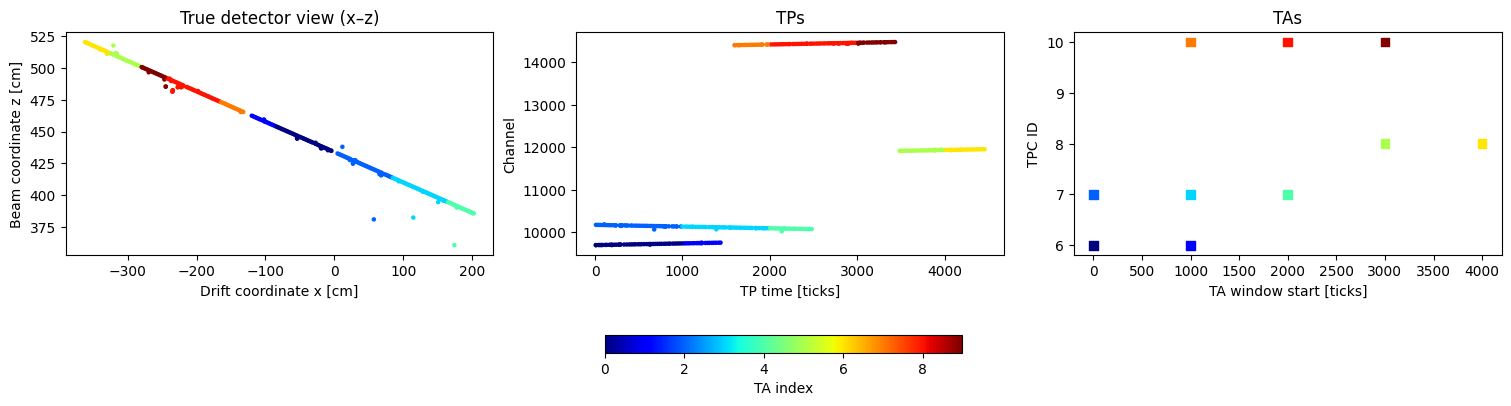

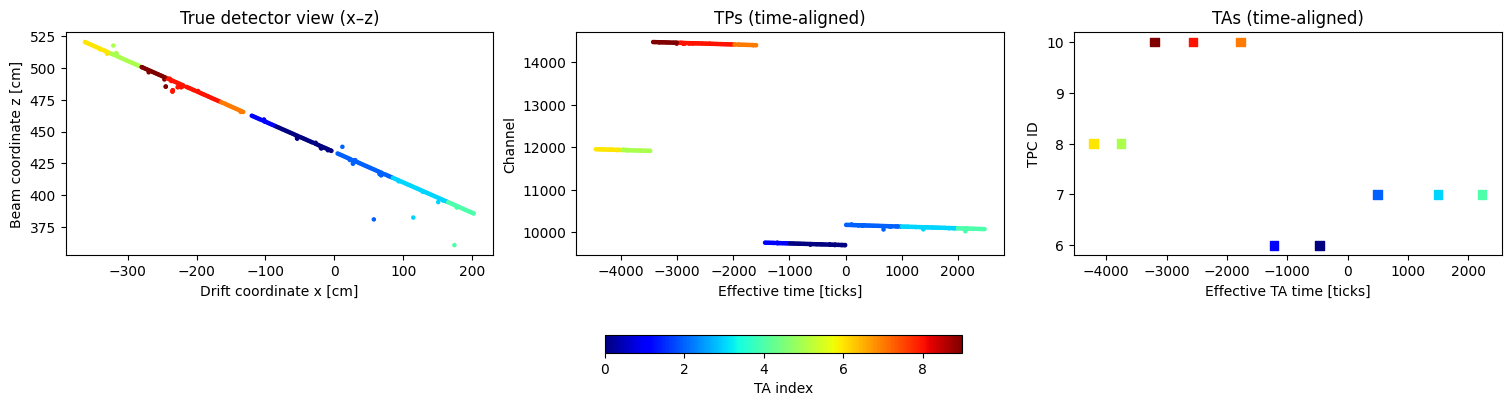

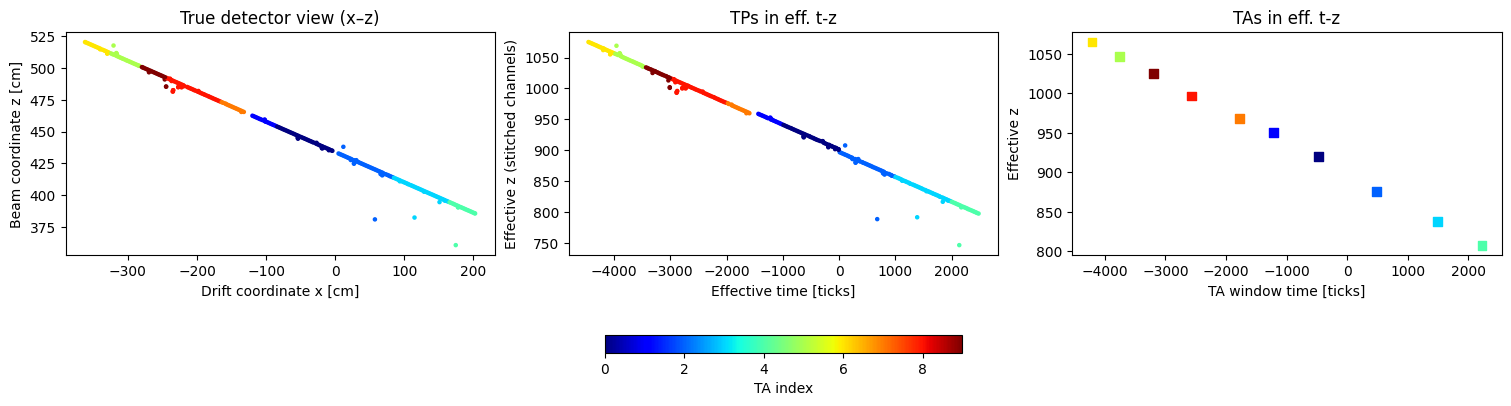

In [217]:
ev = 54705105731594 #cTAs_cosmic.event.unique()[122]  
cmap = 'jet'
tas = cTAs_cosmic[(cTAs_cosmic.event_uid == ev) & (cTAs_cosmic.flag == 2)].copy()
tps = cTPs_cosmic[(cTPs_cosmic.event_uid == ev) & (cTPs_cosmic.bt_edep > 0) & (cTPs_cosmic.TA_id.isin(tas.TA_id.unique()))].copy()

tps["voxel"] = tps["tpc"].map(TPC_ID_TO_INDEX)
tas["voxel"] = tas["tpc"].map(TPC_ID_TO_INDEX)

# Helper functions
def apply_effective_time(df, time_col, out_col):
    df[out_col] = np.where(df.voxel.str[0] == 0, -df[time_col], df[time_col])

def apply_effective_z(df):
    ncol_per_plane = 960 // 2
    df["ch_offset"] = df["tpc"].map(predict_min_channel)
    ch = df["channel"] if "channel" in df.columns else df["ch_wmean"]
    df["eff_z"] = (ch - df["ch_offset"]) + df.voxel.str[2] * ncol_per_plane

def ta_colour(series):
    return series - series.min()

def create_plot(tps_data, tas_data, case_title, x_labels, y_labels, plot_titles):
    fig, ax = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)

    sc = ax[0].scatter(tps_data[0], tps_data[1], c=ta_colour(tps_data[2]), s=5, cmap=cmap)
    ax[0].set_xlabel(x_labels[0])
    ax[0].set_ylabel(y_labels[0])
    ax[0].set_title(plot_titles[0])

    ax[1].scatter(tps_data[3], tps_data[4], c=ta_colour(tps_data[2]), s=5, cmap=cmap)
    ax[1].set_xlabel(x_labels[1])
    ax[1].set_ylabel(y_labels[1])
    ax[1].set_title(plot_titles[1])

    ax[2].scatter(tas_data[0], tas_data[1], c=ta_colour(tas_data[2]), s=40, marker="s", cmap=cmap)
    ax[2].set_xlabel(x_labels[2])
    ax[2].set_ylabel(y_labels[2])
    ax[2].set_title(plot_titles[2])
    cbar = fig.colorbar(sc, ax=ax, orientation="horizontal", fraction=0.08, pad=0.15)
    cbar.set_label("TA index")
    plt.show()

# Apply transformations
apply_effective_time(tps, "time_start", "eff_t")
apply_effective_time(tas, "t_mean", "ta_start_time")
apply_effective_z(tps)
apply_effective_z(tas)


#True detector + raw readout + TA time vs TPC
create_plot(
    [tps.bt_x, tps.bt_z, tps.TA_id, tps.time_start, tps.channel],
    [tas.window_start, tas.tpc, tas.TA_id],
    "Case 1", 
    ["Drift coordinate x [cm]", "TP time [ticks]", "TA window start [ticks]"],
    ["Beam coordinate z [cm]", "Channel", "TPC ID"],
    ["True detector view (x–z)", "TPs", "TAs"]
)

#  True detector + time-aligned readout + aligned TA time
create_plot(
    [tps.bt_x, tps.bt_z, tps.TA_id, tps.eff_t, tps.channel],
    [tas.ta_start_time, tas.tpc, tas.TA_id],
    "Case 2",
    ["Drift coordinate x [cm]", "Effective time [ticks]", "Effective TA time [ticks]"],
    ["Beam coordinate z [cm]", "Channel", "TPC ID"],
    ["True detector view (x–z)", "TPs (time-aligned)", "TAs (time-aligned)"]
)

# True detector + fully stitched trigger coordinates
create_plot(
    [tps.bt_x, tps.bt_z, tps.TA_id, tps.eff_t, tps.eff_z],
    [tas.ta_start_time, tas.eff_z, tas.TA_id],
    "Case 3",
    ["Drift coordinate x [cm]", "Effective time [ticks]", "TA window time [ticks]"],
    ["Beam coordinate z [cm]", "Effective z (stitched channels)", "Effective z"],
    ["True detector view (x–z)", "TPs in eff. t-z", "TAs in eff. t-z"]
)


# TC merging 

In [218]:
# make sure the delta for each adjacent TA is 1 in all directions --> requires dividing window time start by window size 
window_size = 1000
tas["it"] = (tas["window_start"] // window_size) #+ tas["event"] + 10 #separate events should have separate timestamps 

tas["ix"] = tas["voxel"].str[0].astype(int)
tas["iy"] = tas["voxel"].str[1].astype(int)
tas["iz"] = tas["voxel"].str[2].astype(int)

#hash map - map each voxel + time window to the unique TA id 
#(in principle should allow to quickly check whether a neighbouring voxel exists, without scanning the whole dataframe.)
voxel_to_ta = { (row.ix, row.iy, row.iz, row.it): row.TA_id for _, row in tas.iterrows() }
display(voxel_to_ta)

#union–find (disjoint set)
parent = {ta_id: ta_id for ta_id in tas["TA_id"]} #initialisation - each TA is it's own  `parent` or a `seed`

def find(i):
    while parent[i] != i:
        parent[i] = parent[parent[i]]
        i = parent[i]
    return i

def union(i, j):
    ri, rj = find(i), find(j)
    if ri != rj:
        parent[rj] = ri

# voxel adjecency merging 
neigh = [-1, 0, 1]

for _, row in tas.iterrows():
    i = row.TA_id
    for dx in neigh:
        for dy in neigh:
            for dz in neigh:
                for dt in neigh:
                    if dx == dy == dz == dt == 0:
                        continue
                    nkey = (row.ix + dx, row.iy + dy, row.iz + dz, row.it + dt)
                    j = voxel_to_ta.get(nkey)
                    if j is not None:
                        union(i, j)

tas["TC_id"] = tas["TA_id"].map(find)


display(tas)


{(0, 1, 1, 0): 26949,
 (0, 1, 1, 1): 26950,
 (1, 1, 1, 0): 26951,
 (1, 1, 1, 1): 26952,
 (1, 1, 1, 2): 26953,
 (0, 0, 2, 3): 26954,
 (0, 0, 2, 4): 26955,
 (0, 1, 2, 1): 26956,
 (0, 1, 2, 2): 26957,
 (0, 1, 2, 3): 26958}

,event,apa_id,tpc,rop,window_start,flag,TA_id,total_window_energy,TP_count,n_clusters,...,event_uid,voxel,ta_start_time,ch_offset,eff_z,it,ix,iy,iz,TC_id
21914,54705105731594,3,6,2,0,2,26949,1442990,50,-1,...,54705105731594,"(0, 1, 1)",-468.820000,9280,920.177375,0,0,1,1,26949
21915,54705105731594,3,6,2,1000,2,26950,668572,21,-1,...,54705105731594,"(0, 1, 1)",-1221.333333,9280,950.607661,1,0,1,1,26949
21916,54705105731594,3,7,3,0,2,26951,1670101,52,-1,...,54705105731594,"(1, 1, 1)",488.884615,9760,876.353172,0,1,1,1,26949
21917,54705105731594,3,7,3,1000,2,26952,1318936,45,-1,...,54705105731594,"(1, 1, 1)",1498.644444,9760,837.828560,1,1,1,1,26949
21918,54705105731594,3,7,3,2000,2,26953,578376,23,-1,...,54705105731594,"(1, 1, 1)",2228.652174,9760,807.983200,2,1,1,1,26949
21919,54705105731594,4,8,2,3000,2,26954,681440,27,-1,...,54705105731594,"(0, 0, 2)",-3754.185185,11840,1046.853158,3,0,0,2,26949
21920,54705105731594,4,8,2,4000,2,26955,589682,22,-1,...,54705105731594,"(0, 0, 2)",-4212.454545,11840,1065.103949,4,0,0,2,26949
21921,54705105731594,5,10,2,1000,2,26956,554303,18,-1,...,54705105731594,"(0, 1, 2)",-1778.666667,14400,968.086000,1,0,1,2,26949
21922,54705105731594,5,10,2,2000,2,26957,1380114,51,-1,...,54705105731594,"(0, 1, 2)",-2563.196078,14400,996.858728,2,0,1,2,26949
21923,54705105731594,5,10,2,3000,2,26958,510432,22,-1,...,54705105731594,"(0, 1, 2)",-3196.181818,14400,1025.197787,3,0,1,2,26949


# TCMaker 

In [ ]:
def merge_tas(df):
    df['voxel'] = df['tpc'].map(TPC_ID_TO_INDEX)
    window_size = 1000
    df["it"] = (df["window_start"] // window_size)
    df["ix"] = df["voxel"].str[0].astype(int)
    df["iy"] = df["voxel"].str[1].astype(int)
    df["iz"] = df["voxel"].str[2].astype(int)
    

    #merging 
    neigh = [-1, 0, 1]
    df["TC_id"] = -1
    tc_offset = 0  # keep track of global TC_id

    for event_uid, event_df in df.groupby("event"):
        event_df = event_df.copy()
        voxel_to_ta = {
            (row.ix, row.iy, row.iz, row.it): row.TA_id
            for _, row in event_df.iterrows()
        }

        parent = {ta_id: ta_id for ta_id in event_df["TA_id"]}

        def find(i):
            while parent[i] != i:
                parent[i] = parent[parent[i]]
                i = parent[i]
            return i

        def union(i, j):
            ri, rj = find(i), find(j)
            if ri != rj:
                parent[rj] = ri

        for _, row in event_df.iterrows():
            i = row.TA_id
            for dx in neigh:
                for dy in neigh:
                    for dz in neigh:
                        for dt in neigh:
                            if dx == dy == dz == dt == 0:
                                continue
                            nkey = (row.ix + dx, row.iy + dy, row.iz + dz, row.it + dt)
                            j = voxel_to_ta.get(nkey)
                            if j is not None:
                                union(i, j)

        TC_ids = {ta_id: find(ta_id) for ta_id in event_df["TA_id"]}
        unique_roots = {r: i + tc_offset for i, r in enumerate(sorted(set(TC_ids.values())))}
        event_df["TC_id"] = event_df["TA_id"].map(lambda x: unique_roots[TC_ids[x]])

        df.loc[event_df.index, "TC_id"] = event_df["TC_id"]
        tc_offset += len(unique_roots)

    return df

cTCs_cosmic = merge_tas(cTAs_cosmic[cTAs_cosmic.flag==2])

In [ ]:
def merge_tas_tacentric(df):
    df = df.copy()
    df["voxel"] = df["tpc"].map(TPC_ID_TO_INDEX)
    window_size = 1000
    df["it"] = (df["window_start"] // window_size).astype(int)
    df["ix"] = df["voxel"].str[0].astype(int)
    df["iy"] = df["voxel"].str[1].astype(int)
    df["iz"] = df["voxel"].str[2].astype(int)
    df["TC_id"] = -1
    tc_offset = 0

    for event_uid, event_df in df.groupby("event"):

        event_df = event_df.copy()
        tas_by_it = {}
        for _, row in event_df.iterrows():
            tas_by_it.setdefault(row.it, []).append(row)
        parent = {ta_id: ta_id for ta_id in event_df["TA_id"]}

        def find(i):
            while parent[i] != i:
                parent[i] = parent[parent[i]]
                i = parent[i]
            return i
        
        def union(i, j):
            ri = find(i)
            rj = find(j)
            if ri != rj:
                parent[rj] = ri

        for _, row in event_df.iterrows():
            i = row.TA_id
            ix = row.ix
            iy = row.iy
            iz = row.iz
            it = row.it
            for it2 in (it, it - 1): #list of TAs in the relevant time slice --> new TAs only attach to TAs from the same or previous window (if they are space-adjacent)
                for other in tas_by_it.get(it2, []):
                    j = other.TA_id
                    if i == j:
                        continue
                    if abs(ix - other.ix) <= 1 and abs(iy - other.iy) <= 1 and abs(iz - other.iz) <= 1:
                        union(i, j)

        roots = {ta_id: find(ta_id) for ta_id in event_df["TA_id"]}
        unique_roots = {r: i + tc_offset for i, r in enumerate(sorted(set(roots.values())))}
        event_df["TC_id"] = event_df["TA_id"].map(lambda ta: unique_roots[roots[ta]])
        df.loc[event_df.index, "TC_id"] = event_df["TC_id"]
        tc_offset += len(unique_roots)
        
    return df

lTCs_cosmic = merge_tas_tacentric(lTAs_cosmic[lTAs_cosmic.flag==2])

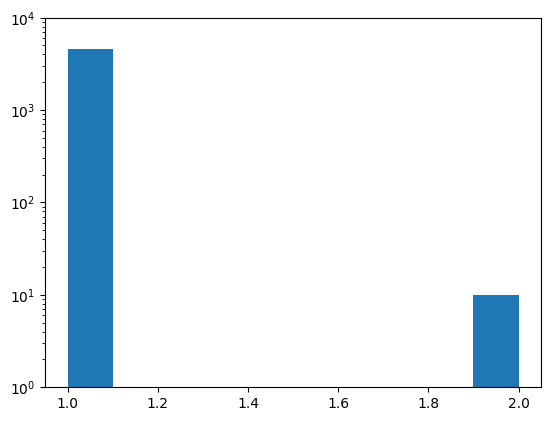

10
[54705002840071, 54705017323530, 54705020796939, 54705024204816, 54705026236421, 54705027088407, 54705035935756, 54705038950415, 54705041375233, 54705068900362]


In [239]:
plt.hist(lTCs_cosmic.groupby("event_uid").TC_id.nunique())
plt.yscale('log')
plt.ylim(1,1e4)
plt.show()

print(len(lTCs_cosmic.groupby("event_uid")["TC_id"].nunique().loc[lambda x: x > 1].index.tolist()))

print(lTCs_cosmic.groupby("event_uid")["TC_id"].nunique().loc[lambda x: x > 1].index.tolist())


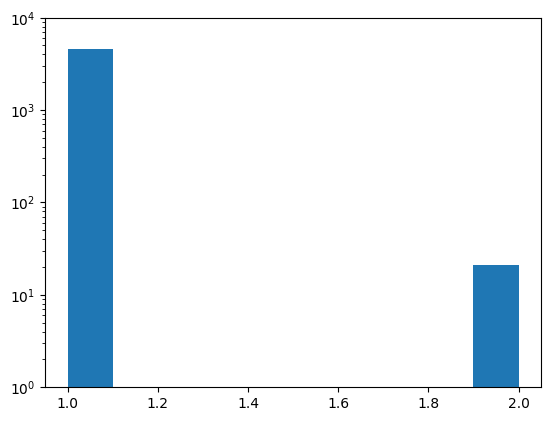

21
[54705002840071, 54705002905621, 54705010245638, 54705011425297, 54705011687454, 54705012539410, 54705020469262, 54705020796939, 54705024204816, 54705026236421, 54705027350531, 54705035870213, 54705035935756, 54705041375233, 54705046421528, 54705046814723, 54705048846349, 54705060118533, 54705064574986, 54705068900362, 54705072898061]


In [203]:
plt.hist(cTCs_cosmic.groupby("event_uid").TC_id.nunique())
plt.yscale('log')
plt.ylim(1,1e4)
plt.show()

print(len(cTCs_cosmic.groupby("event_uid")["TC_id"].nunique().loc[lambda x: x > 1].index.tolist()))

print(cTCs_cosmic.groupby("event_uid")["TC_id"].nunique().loc[lambda x: x > 1].index.tolist())


,event,apa_id,tpc,rop,window_start,flag,TA_id,total_window_energy,TP_count,n_clusters,...,ch_wstd,t_wstd,run,event_uid,voxel,it,ix,iy,iz,TC_id
3675,54705010245638,5,10,2,0,2,4584,1072646,96,-1,...,32.986376,136.128776,12737,54705010245638,"(0, 1, 2)",0,0,1,2,785
3676,54705010245638,5,10,2,1000,2,4585,156498,18,-1,...,18.128364,136.475149,12737,54705010245638,"(0, 1, 2)",1,0,1,2,785
3677,54705010245638,7,14,2,0,2,4586,1851521,127,-1,...,26.058402,133.411044,12737,54705010245638,"(0, 1, 3)",0,0,1,3,785
3678,54705010245638,7,15,3,0,2,4587,1882460,189,-1,...,54.384096,295.104579,12737,54705010245638,"(1, 1, 3)",0,1,1,3,785
3679,54705010245638,7,15,3,1000,2,4588,2230436,204,-1,...,53.650149,288.109369,12737,54705010245638,"(1, 1, 3)",1,1,1,3,785
3680,54705010245638,8,17,3,3000,2,4591,5467636,155,-1,...,28.645403,124.135640,12737,54705010245638,"(1, 0, 4)",3,1,0,4,785
3681,54705010245638,8,17,3,4000,2,4592,8229944,340,-1,...,25.119907,126.961293,12737,54705010245638,"(1, 0, 4)",4,1,0,4,785
3682,54705010245638,9,19,3,2000,2,4593,6058724,327,-1,...,37.644611,197.602954,12737,54705010245638,"(1, 1, 4)",2,1,1,4,785
3683,54705010245638,9,19,3,3000,2,4594,773569,105,-1,...,37.692078,151.361211,12737,54705010245638,"(1, 1, 4)",3,1,1,4,785
22771,54705010245638,7,15,3,2000,2,4589,48687,6,1,...,1.719551,9.969822,12737,54705010245638,"(1, 1, 3)",2,1,1,3,785


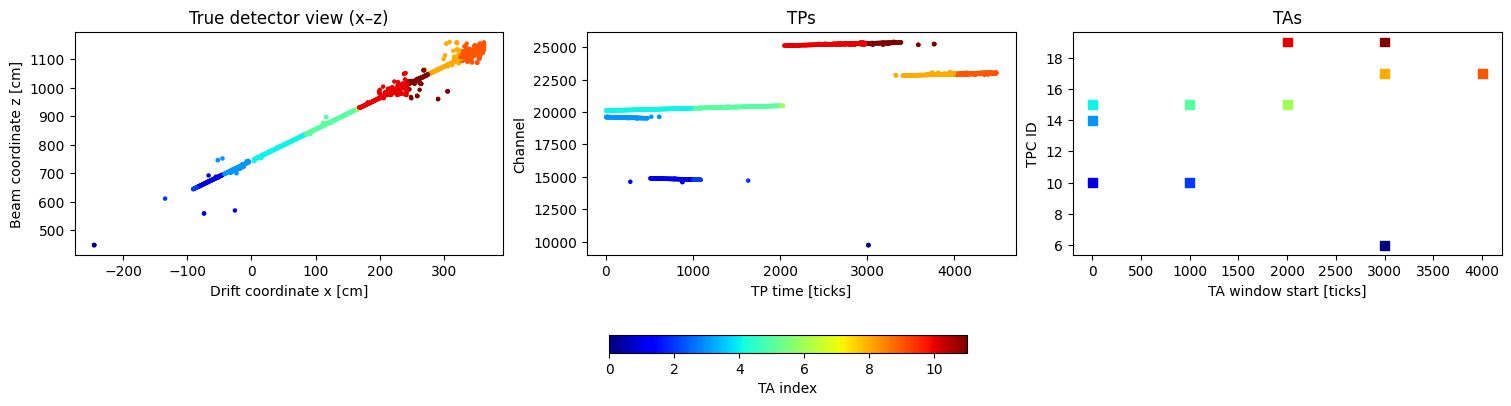

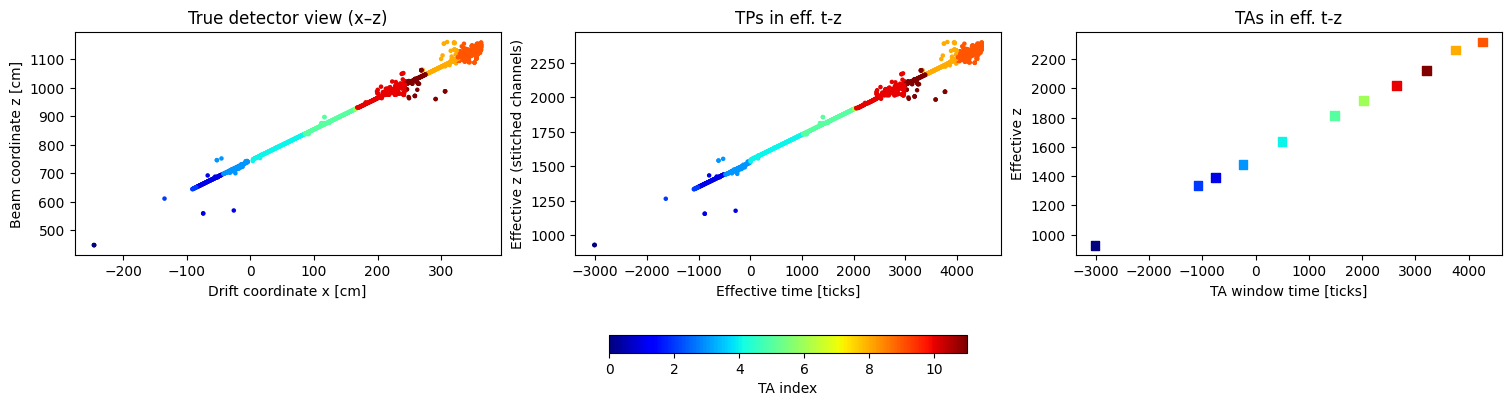

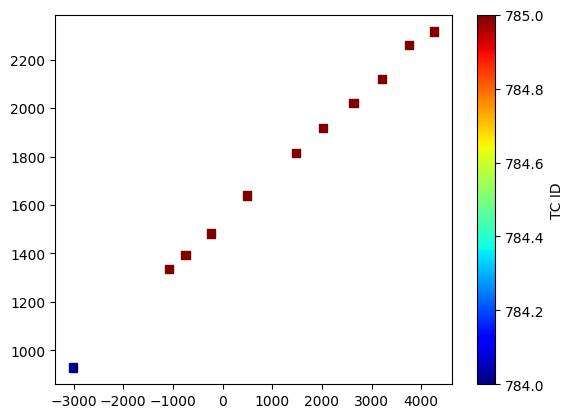

,event,apa_id,tpc,rop,window_start,flag,TA_id,total_window_energy,TP_count,n_clusters,...,ch_wstd,t_wstd,run,event_uid,voxel,it,ix,iy,iz,TC_id
20196,54705072898061,5,10,2,4000,2,24863,2583483,213,-1,...,47.591008,91.409571,12737,54705072898061,"(0, 1, 2)",4,0,1,2,4288
20197,54705072898061,7,14,2,3000,2,24865,3096146,366,-1,...,70.067934,152.000715,12737,54705072898061,"(0, 1, 3)",3,0,1,3,4288
20198,54705072898061,7,14,2,4000,2,24866,348561,50,-1,...,14.694683,30.330557,12737,54705072898061,"(0, 1, 3)",4,0,1,3,4288
23126,54705072898061,7,14,2,1000,2,24864,25892,3,1,...,0.680381,6.231875,12737,54705072898061,"(0, 1, 3)",1,0,1,3,4289


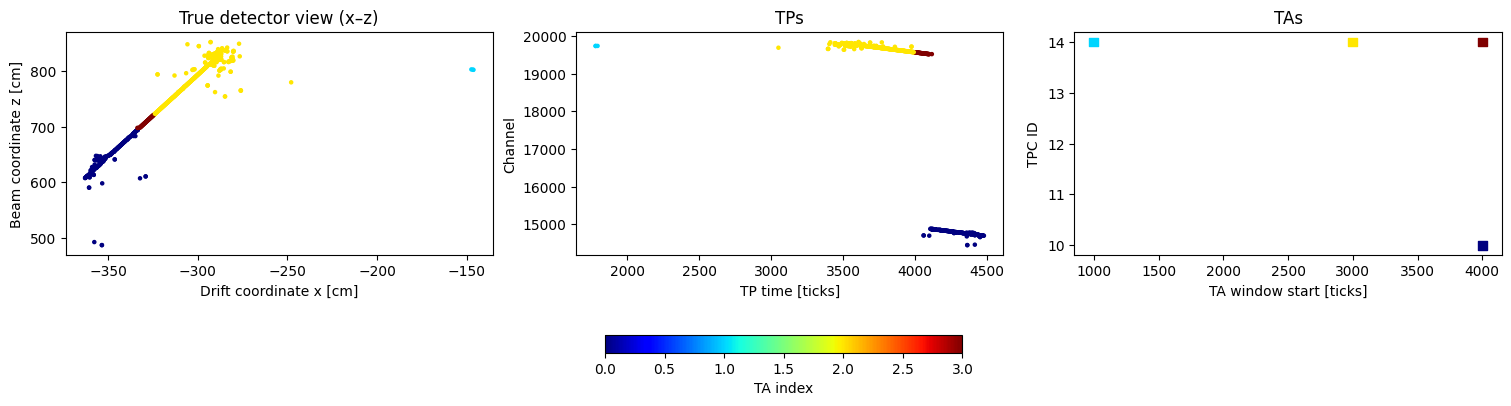

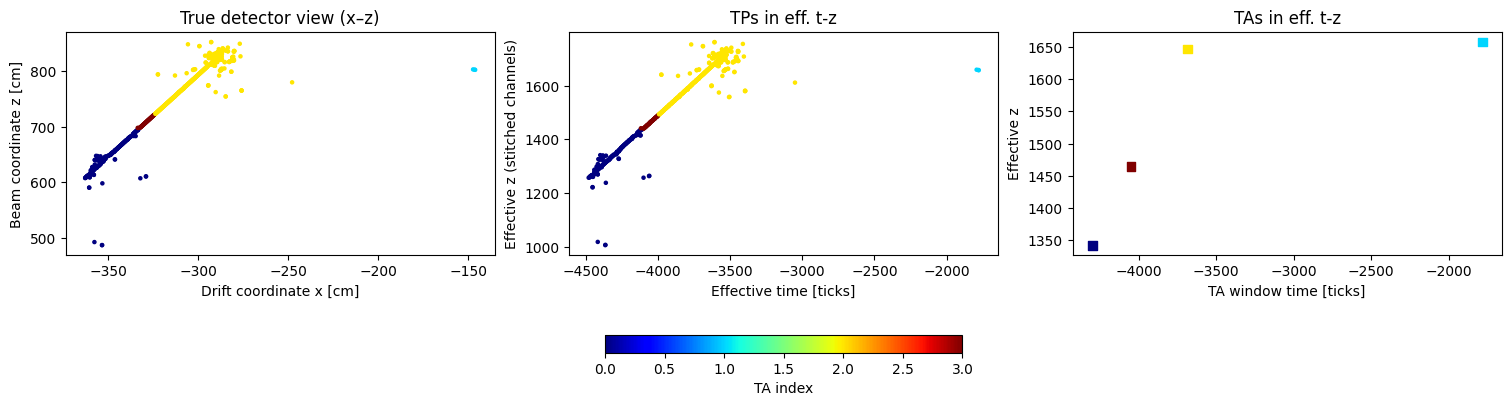

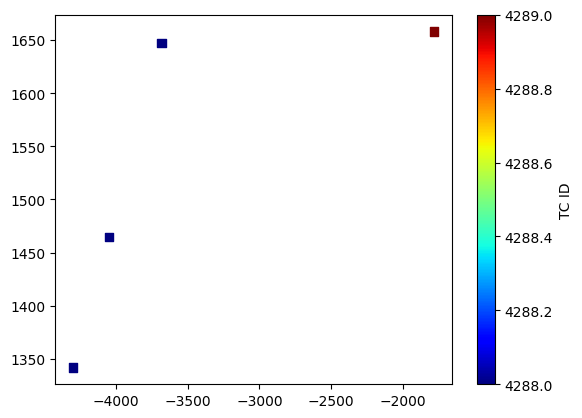

,event,apa_id,tpc,rop,window_start,flag,TA_id,total_window_energy,TP_count,n_clusters,...,ch_wstd,t_wstd,run,event_uid,voxel,it,ix,iy,iz,TC_id
4019,54705011425297,4,9,3,0,2,4993,108223,17,-1,...,60.220610,144.228481,12737,54705011425297,"(1, 0, 2)",0,1,0,2,858
4020,54705011425297,4,9,3,2000,2,4995,170728,15,-1,...,17.544539,87.948738,12737,54705011425297,"(1, 0, 2)",2,1,0,2,859
4021,54705011425297,4,9,3,3000,2,4996,24526034,559,-1,...,19.630998,189.085152,12737,54705011425297,"(1, 0, 2)",3,1,0,2,859
4022,54705011425297,4,9,3,4000,2,4997,1471825,92,-1,...,19.043329,135.609897,12737,54705011425297,"(1, 0, 2)",4,1,0,2,859


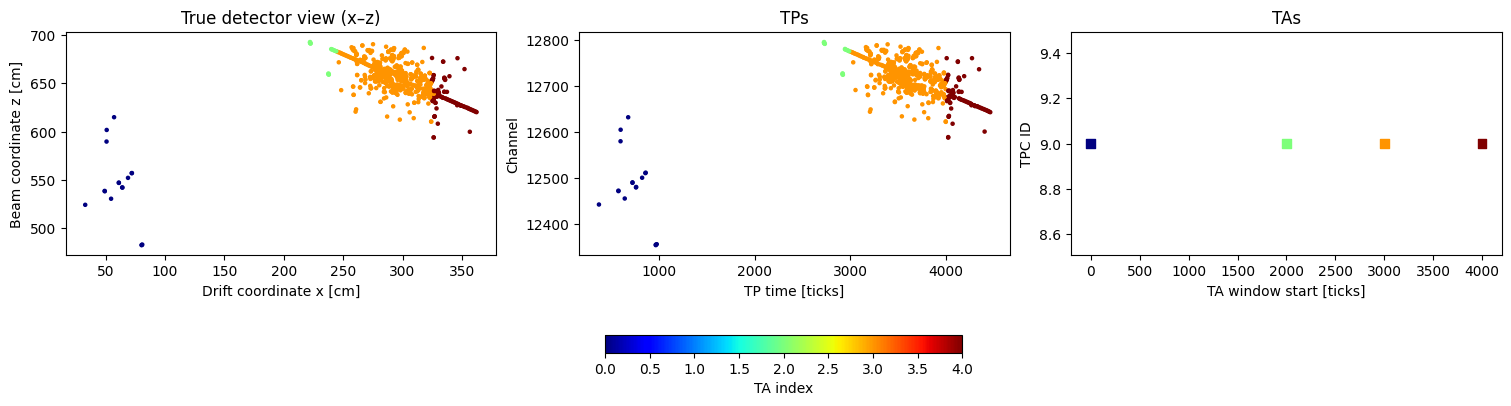

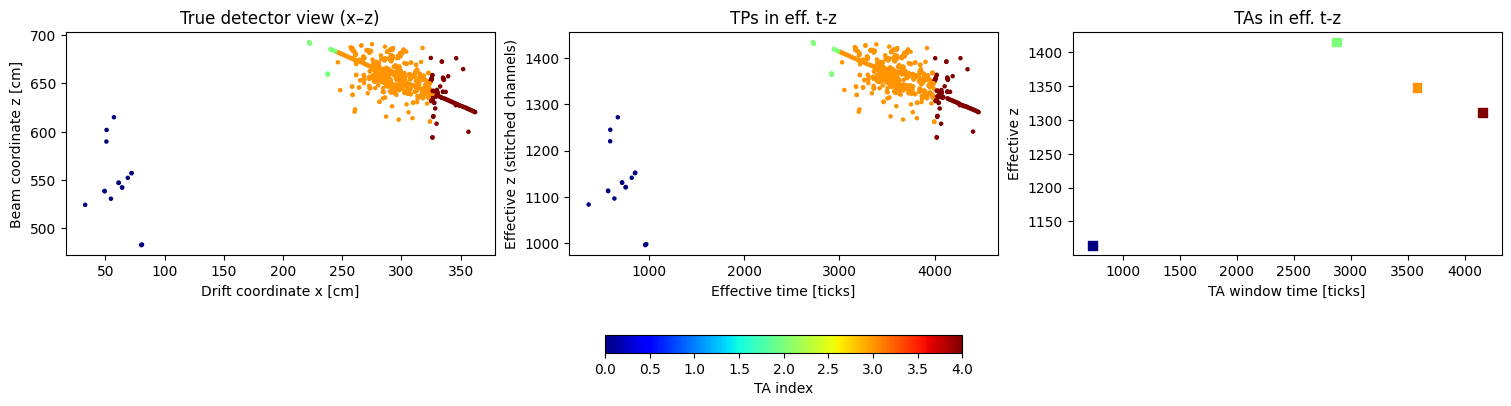

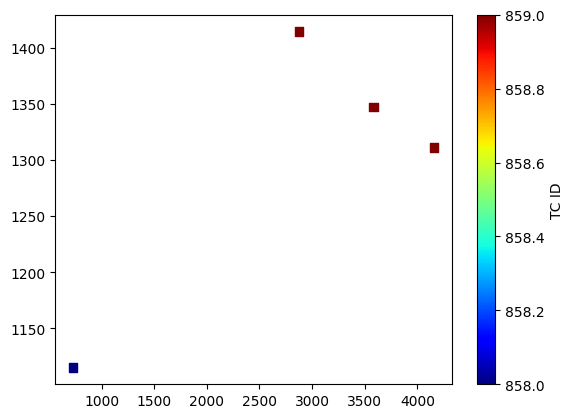

In [236]:
events = [54705010245638, 54705072898061, 54705011425297 ]
for ev in events: 

    tcs = cTCs_cosmic[cTCs_cosmic.event_uid==ev]  

    display(tcs)

    cmap = 'jet'
    tas = cTAs_cosmic[(cTAs_cosmic.event_uid == ev) & (cTAs_cosmic.flag == 2)].copy()
    tps = cTPs_cosmic[(cTPs_cosmic.event_uid == ev) & (cTPs_cosmic.bt_edep > 0) & (cTPs_cosmic.TA_id.isin(tas.TA_id.unique()))].copy()

    tps["voxel"] = tps["tpc"].map(TPC_ID_TO_INDEX)
    tas["voxel"] = tas["tpc"].map(TPC_ID_TO_INDEX)

    # Helper functions
    def apply_effective_time(df, time_col, out_col):
        df[out_col] = np.where(df.voxel.str[0] == 0, -df[time_col], df[time_col])

    def apply_effective_z(df):
        ncol_per_plane = 960 // 2
        df["ch_offset"] = df["tpc"].map(predict_min_channel)
        ch = df["channel"] if "channel" in df.columns else df["ch_wmean"]
        df["eff_z"] = (ch - df["ch_offset"]) + df.voxel.str[2] * ncol_per_plane

    def ta_colour(series):
        return series - series.min()

    def create_plot(tps_data, tas_data, case_title, x_labels, y_labels, plot_titles):
        fig, ax = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)

        sc = ax[0].scatter(tps_data[0], tps_data[1], c=ta_colour(tps_data[2]), s=5, cmap=cmap)
        ax[0].set_xlabel(x_labels[0])
        ax[0].set_ylabel(y_labels[0])
        ax[0].set_title(plot_titles[0])

        ax[1].scatter(tps_data[3], tps_data[4], c=ta_colour(tps_data[2]), s=5, cmap=cmap)
        ax[1].set_xlabel(x_labels[1])
        ax[1].set_ylabel(y_labels[1])
        ax[1].set_title(plot_titles[1])

        ax[2].scatter(tas_data[0], tas_data[1], c=ta_colour(tas_data[2]), s=40, marker="s", cmap=cmap)
        ax[2].set_xlabel(x_labels[2])
        ax[2].set_ylabel(y_labels[2])
        ax[2].set_title(plot_titles[2])

        cbar = fig.colorbar(sc, ax=ax, orientation="horizontal", fraction=0.08, pad=0.15)
        cbar.set_label("TA index")
        plt.show()

    # Apply transformations
    apply_effective_time(tps, "time_start", "eff_t")
    apply_effective_time(tas, "t_mean", "ta_start_time")
    apply_effective_time(tcs, "t_mean", "ta_start_time")
    apply_effective_z(tps)
    apply_effective_z(tas)
    apply_effective_z(tcs)


    #True detector + raw readout + TA time vs TPC
    create_plot(
        [tps.bt_x, tps.bt_z, tps.TA_id, tps.time_start, tps.channel],
        [tas.window_start, tas.tpc, tas.TA_id],
        "Case 1", 
        ["Drift coordinate x [cm]", "TP time [ticks]", "TA window start [ticks]"],
        ["Beam coordinate z [cm]", "Channel", "TPC ID"],
        ["True detector view (x–z)", "TPs", "TAs"]
    )


    # True detector + fully stitched trigger coordinates
    create_plot(
        [tps.bt_x, tps.bt_z, tps.TA_id, tps.eff_t, tps.eff_z],
        [tas.ta_start_time, tas.eff_z, tas.TA_id],
        "Case 3",
        ["Drift coordinate x [cm]", "Effective time [ticks]", "TA window time [ticks]"],
        ["Beam coordinate z [cm]", "Effective z (stitched channels)", "Effective z"],
        ["True detector view (x–z)", "TPs in eff. t-z", "TAs in eff. t-z"]
    )

    plt.scatter(tcs.ta_start_time, tcs.eff_z, c=tcs.TC_id, marker='s', cmap='jet')
    plt.colorbar().set_label("TC ID")
    plt.show()


,event,apa_id,tpc,rop,window_start,flag,TA_id,total_window_energy,TP_count,n_clusters,...,ch_wstd,t_wstd,run,event_uid,voxel,it,ix,iy,iz,TC_id
5598,54705017323530,0,1,3,2000,2,7233,7393028,330,-1,...,45.947825,239.388098,12737,54705017323530,"(1, 0, 0)",2,1,0,0,1218
21057,54705017323530,0,1,3,0,2,7231,129877,11,2,...,0.673128,9.465790,12737,54705017323530,"(1, 0, 0)",0,1,0,0,1217


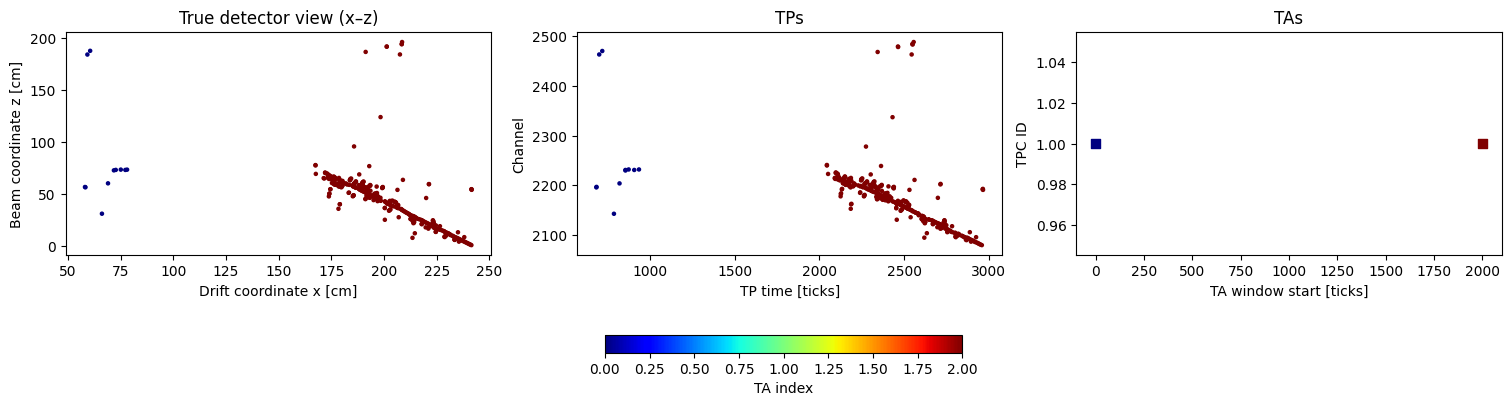

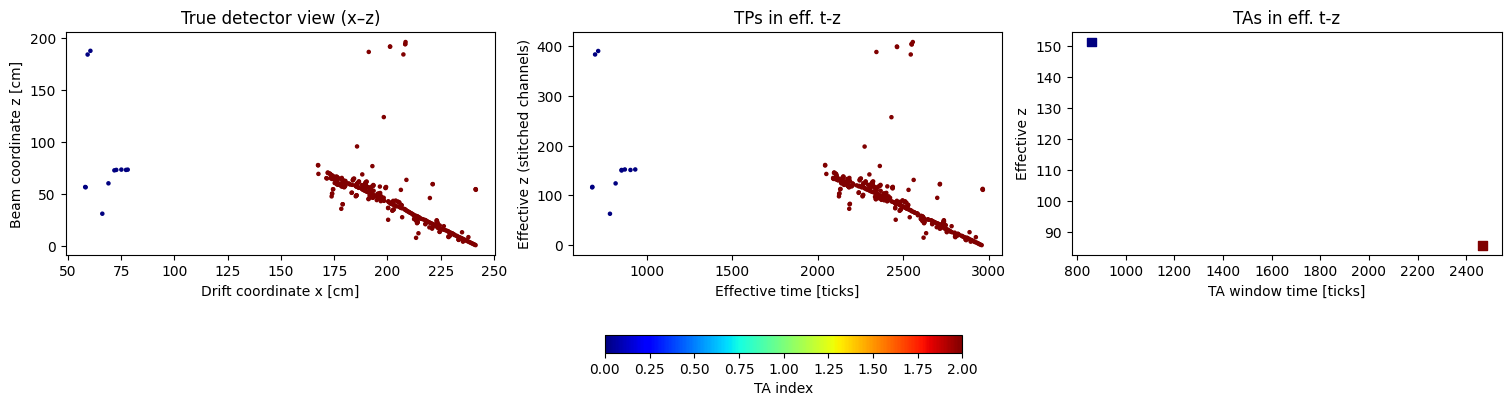

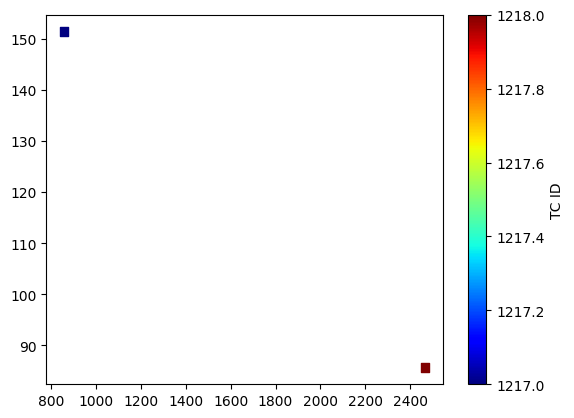

,event,apa_id,tpc,rop,window_start,flag,TA_id,total_window_energy,TP_count,n_clusters,...,ch_wstd,t_wstd,run,event_uid,voxel,it,ix,iy,iz,TC_id
8578,54705027088407,10,20,2,1000,2,11095,28244270,406,-1,...,9.601377,109.597206,12737,54705027088407,"(0, 0, 5)",1,0,0,5,1880
23554,54705027088407,11,22,2,3000,2,11097,55145,4,1,...,0.777633,1.268556,12737,54705027088407,"(0, 1, 5)",3,0,1,5,1881
23568,54705027088407,10,20,2,0,2,11094,66778,11,2,...,1.063398,2.366031,12737,54705027088407,"(0, 0, 5)",0,0,0,5,1880


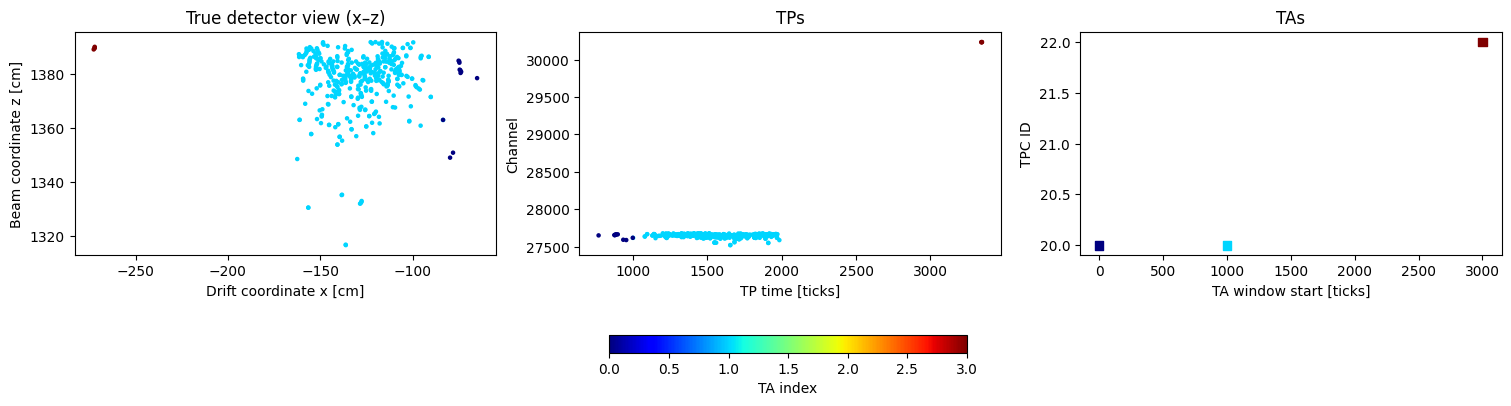

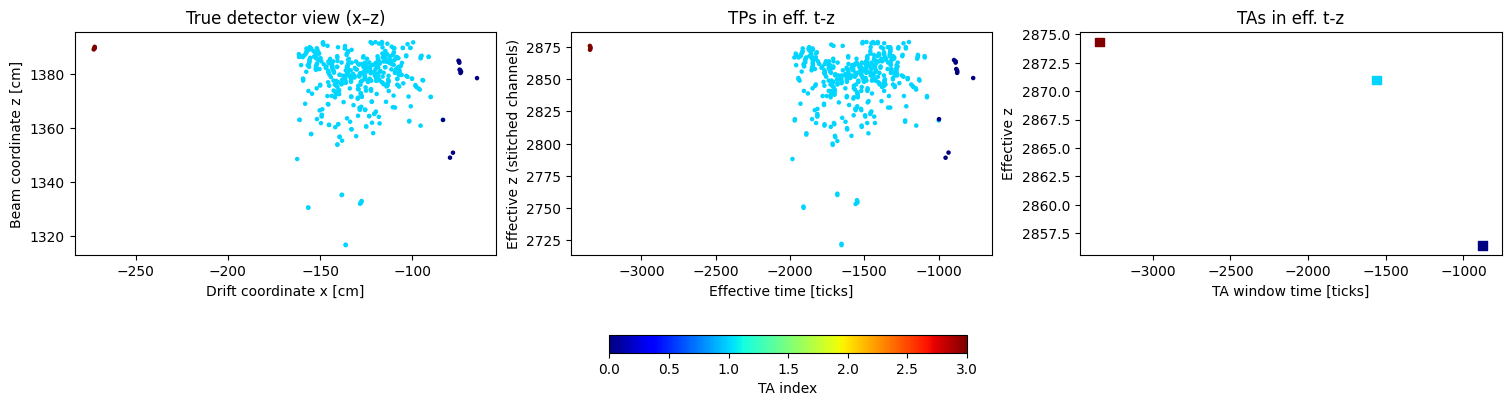

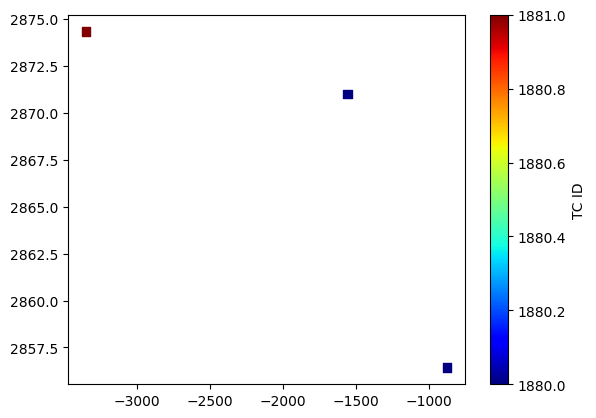

,event,apa_id,tpc,rop,window_start,flag,TA_id,total_window_energy,TP_count,n_clusters,...,ch_wstd,t_wstd,run,event_uid,voxel,it,ix,iy,iz,TC_id
12231,54705038950415,0,1,3,4000,2,15725,147587,37,-1,...,75.135230,134.997185,12737,54705038950415,"(1, 0, 0)",4,1,0,0,2680
23024,54705038950415,0,1,3,2000,2,15723,105431,19,4,...,1.989293,15.088853,12737,54705038950415,"(1, 0, 0)",2,1,0,0,2679


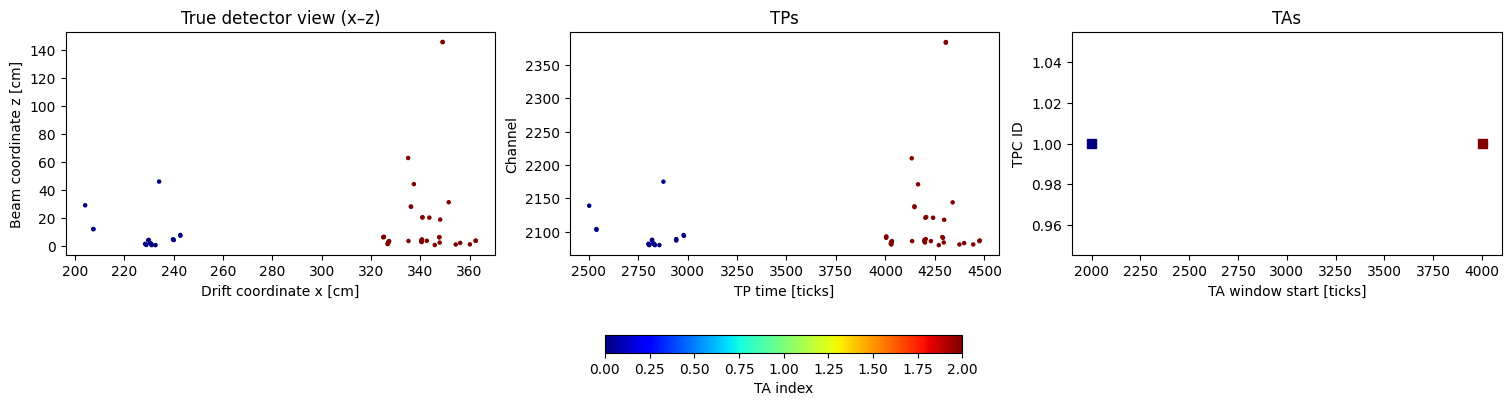

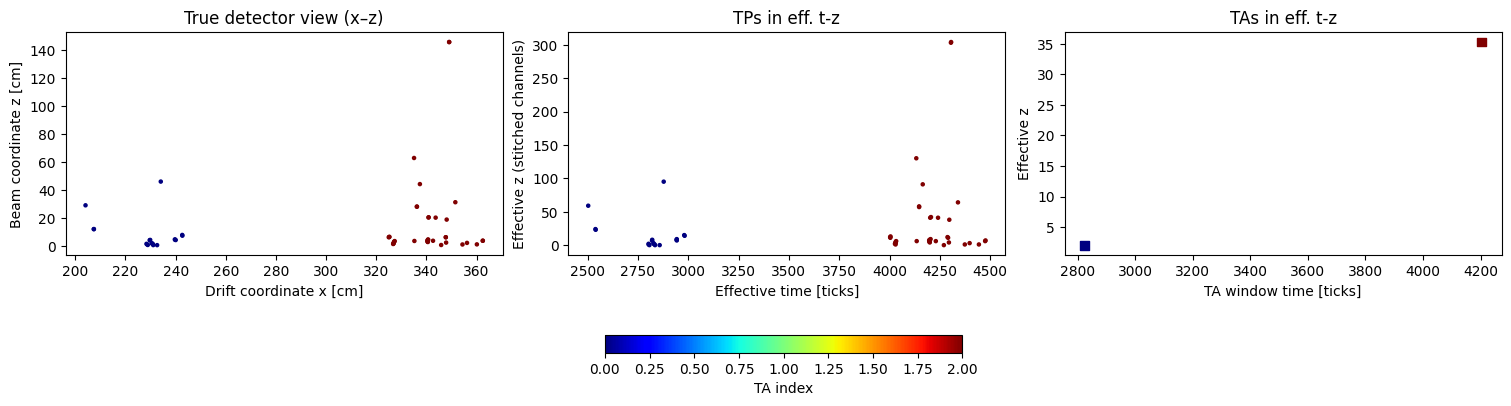

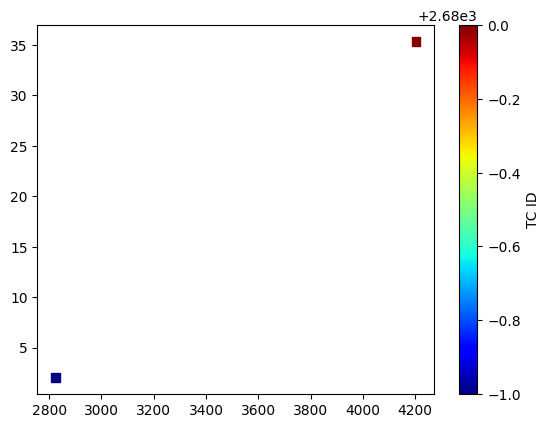

In [246]:
x1 = [54705002840071, 54705017323530, 54705020796939, 54705024204816, 54705026236421, 54705027088407, 54705035935756, 54705038950415, 54705041375233, 54705068900362]
x2 = [54705002840071, 54705002905621, 54705010245638, 54705011425297, 54705011687454, 54705012539410, 54705020469262, 54705020796939, 54705024204816, 54705026236421, 54705027350531, 54705035870213, 54705035935756, 54705041375233, 54705046421528, 54705046814723, 54705048846349, 54705060118533, 54705064574986, 54705068900362, 54705072898061]
missing = [item for item in x1 if item not in x2]

events = missing 
for ev in events: 

    tcs = lTCs_cosmic[lTCs_cosmic.event_uid==ev]  

    display(tcs)

    cmap = 'jet'
    tas = lTAs_cosmic[(lTAs_cosmic.event_uid == ev) & (lTAs_cosmic.flag == 2)].copy()
    tps = lTPs_cosmic[(lTPs_cosmic.event_uid == ev) & (lTPs_cosmic.bt_edep > 0) & (lTPs_cosmic.TA_id.isin(tas.TA_id.unique()))].copy()

    tps["voxel"] = tps["tpc"].map(TPC_ID_TO_INDEX)
    tas["voxel"] = tas["tpc"].map(TPC_ID_TO_INDEX)

    # Helper functions
    def apply_effective_time(df, time_col, out_col):
        df[out_col] = np.where(df.voxel.str[0] == 0, -df[time_col], df[time_col])

    def apply_effective_z(df):
        ncol_per_plane = 960 // 2
        df["ch_offset"] = df["tpc"].map(predict_min_channel)
        ch = df["channel"] if "channel" in df.columns else df["ch_wmean"]
        df["eff_z"] = (ch - df["ch_offset"]) + df.voxel.str[2] * ncol_per_plane

    def ta_colour(series):
        return series - series.min()

    def create_plot(tps_data, tas_data, case_title, x_labels, y_labels, plot_titles):
        fig, ax = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)

        sc = ax[0].scatter(tps_data[0], tps_data[1], c=ta_colour(tps_data[2]), s=5, cmap=cmap)
        ax[0].set_xlabel(x_labels[0])
        ax[0].set_ylabel(y_labels[0])
        ax[0].set_title(plot_titles[0])

        ax[1].scatter(tps_data[3], tps_data[4], c=ta_colour(tps_data[2]), s=5, cmap=cmap)
        ax[1].set_xlabel(x_labels[1])
        ax[1].set_ylabel(y_labels[1])
        ax[1].set_title(plot_titles[1])

        ax[2].scatter(tas_data[0], tas_data[1], c=ta_colour(tas_data[2]), s=40, marker="s", cmap=cmap)
        ax[2].set_xlabel(x_labels[2])
        ax[2].set_ylabel(y_labels[2])
        ax[2].set_title(plot_titles[2])

        cbar = fig.colorbar(sc, ax=ax, orientation="horizontal", fraction=0.08, pad=0.15)
        cbar.set_label("TA index")
        plt.show()

    # Apply transformations
    apply_effective_time(tps, "time_start", "eff_t")
    apply_effective_time(tas, "t_mean", "ta_start_time")
    apply_effective_time(tcs, "t_mean", "ta_start_time")
    apply_effective_z(tps)
    apply_effective_z(tas)
    apply_effective_z(tcs)


    #True detector + raw readout + TA time vs TPC
    create_plot(
        [tps.bt_x, tps.bt_z, tps.TA_id, tps.time_start, tps.channel],
        [tas.window_start, tas.tpc, tas.TA_id],
        "Case 1", 
        ["Drift coordinate x [cm]", "TP time [ticks]", "TA window start [ticks]"],
        ["Beam coordinate z [cm]", "Channel", "TPC ID"],
        ["True detector view (x–z)", "TPs", "TAs"]
    )


    # True detector + fully stitched trigger coordinates
    create_plot(
        [tps.bt_x, tps.bt_z, tps.TA_id, tps.eff_t, tps.eff_z],
        [tas.ta_start_time, tas.eff_z, tas.TA_id],
        "Case 3",
        ["Drift coordinate x [cm]", "Effective time [ticks]", "TA window time [ticks]"],
        ["Beam coordinate z [cm]", "Effective z (stitched channels)", "Effective z"],
        ["True detector view (x–z)", "TPs in eff. t-z", "TAs in eff. t-z"]
    )

    plt.scatter(tcs.ta_start_time, tcs.eff_z, c=tcs.TC_id, marker='s', cmap='jet')
    plt.colorbar().set_label("TC ID")
    plt.show()


x= cosmic_evsum[cosmic_evsum.event_uid.isin(cTCs_cosmic.event.unique())].sort_values("event_uid")
y = cTCs_cosmic.sort_values("event")

plt.hist2d(x.groupby("event_uid").visible_energy.first()/1e4, y.groupby("event_uid").total_window_energy.sum()/1e6,  bins = (100,100), norm = LogNorm(), range= [(0,1.5), (0,60)])
plt.xlabel("true visible energy [GeV]")
plt.colorbar()
plt.ylabel(" energy in TCs [MSADC]")
plt.show()

# Beam vs. cosmic TAs

In [ ]:
#Load MC beam info 
for data_type in ["mc", "nu", "sum"]:
    for part in ["nue", "numu"]:
        globals()[f"{part}_{data_type}"] = pd.read_pickle(f"./beam/genie_{part}_{data_type}.pkl")
        #get_unique_event_ids(globals()[f"{part}_{data_type}"])
        globals()[f"{part}_{data_type}"] = globals()[f"{part}_{data_type}"].sort_values(by="event_uid")

#Load TAs
for part in ["nue", "numu"]:
    globals()[f"trig_{part}_cent"] = pd.read_pickle(f"./trigger_data/beamTAs_{part}_cbgd.pkl")
    globals()[f"trig_{part}_lat"] = pd.read_pickle(f"./trigger_data/beamTAs_{part}_lbgd.pkl")

    globals()[f"beam_{part}_ctps"] = pd.read_pickle(f"./trigger_data/beam_chunks/{part}_TPs_cbgd_6.pkl")
 

    nu = globals()[f"{part}_nu"]
    mc = globals()[f"{part}_mc"]

    if part == "nue":
            mc = mc[(mc.pdg==12) & (mc.status_code==0)]
    else:
         mc =mc[(mc.pdg==14) & (mc.status_code==0)]

    globals()[f"trig_beam_{part}_lat"] = pd.merge(globals()[f"trig_{part}_lat"], nu[['event','run','mode','ccnc']], on=['event','run'], how='inner')
    globals()[f"trig_beam_{part}_cent"] = pd.merge(globals()[f"trig_{part}_cent"], nu[['event','run','mode','ccnc']], on=['event','run'], how='inner')

    globals()[f"trig_beam_{part}_lat"] = pd.merge(globals()[f"trig_beam_{part}_lat"], mc[['event','run','energy','x', 'y', 'z']], on=['event','run'], how='inner')
    globals()[f"trig_beam_{part}_cent"] = pd.merge(globals()[f"trig_beam_{part}_cent"], mc[['event','run','energy','x', 'y', 'z']], on=['event','run'], how='inner')


print("number of nu_e beam events: ", nue_sum.event_uid.nunique())
print("number of nu_mu beam events: ", numu_sum.event_uid.nunique())


    
display(trig_beam_nue_lat)

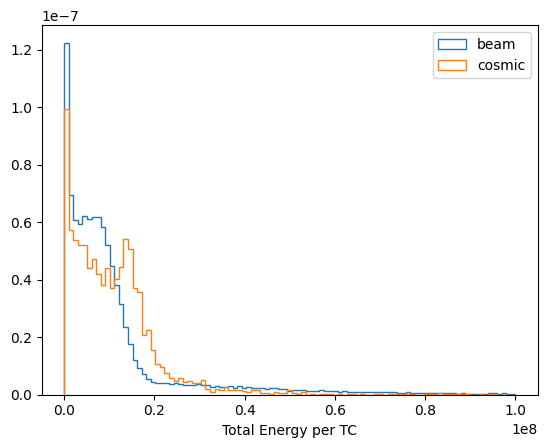

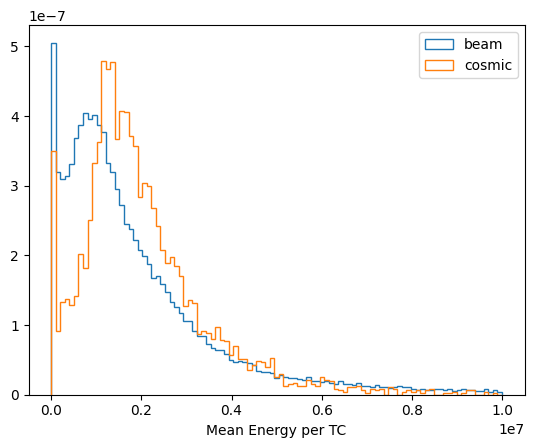

In [225]:
bins = np.linspace(0,0.1e9, 100)
params = {"bins": bins, "density":True, "histtype":'step'}

plt.hist(trig_beam_nue_cent.groupby("event_uid").total_window_energy.sum(), **params, label ='beam')
plt.hist(cTAs_cosmic.groupby("event").total_window_energy.sum(), **params, label = 'cosmic')
plt.legend()
plt.xlabel("Total Energy per TC")
plt.show()

bins = np.linspace(0,0.1e8, 100)
params = {"bins": bins, "density":True, "histtype":'step'}

plt.hist(trig_beam_nue_cent.groupby("event_uid").total_window_energy.sum()/trig_beam_nue_cent.groupby("event_uid").size(), **params, label ='beam')
plt.hist(cTAs_cosmic.groupby("event").total_window_energy.sum()/cTAs_cosmic.groupby("event").size(), **params, label = 'cosmic')
plt.legend()
plt.xlabel("Mean Energy per TC")
plt.show()

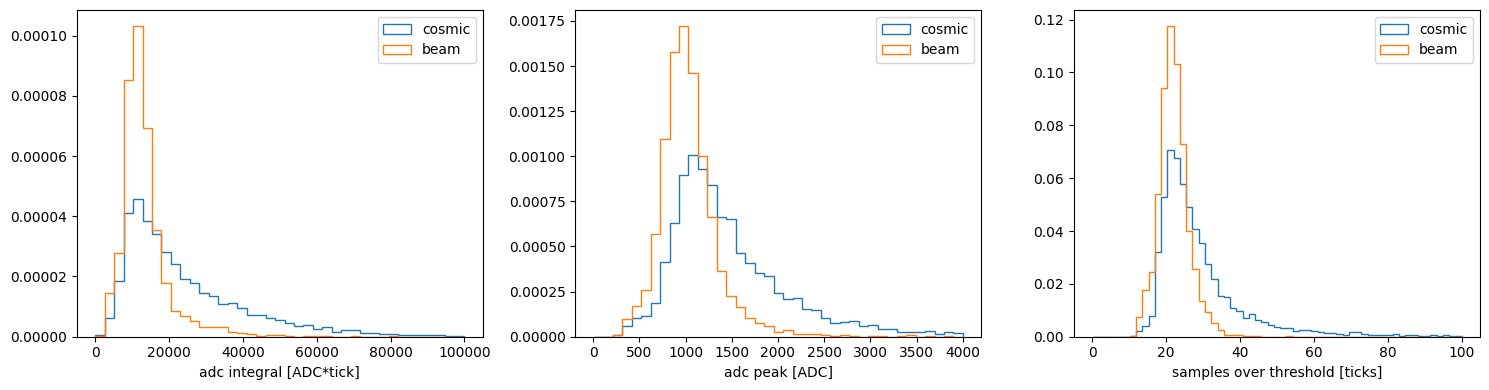

In [237]:


fig, axs = plt.subplots(1, 3, figsize=(15, 4))


params = {"bins": np.linspace(8, 100e3, 40), "density": True, "histtype": 'step'}
axs[0].hist(cTPs_cosmic.groupby("event").adc_integral.mean(), **params, label='cosmic')
axs[0].hist(beam_nue_ctps.groupby("event_uid").adc_integral.mean(), **params, label='beam')
axs[0].set_xlabel("adc integral [ADC*tick]")
axs[0].legend()

params = {"bins": np.linspace(8, 4e3, 40), "density": True, "histtype": 'step'}
axs[1].hist(cTPs_cosmic.groupby("event").adc_peak.mean(), **params, label='cosmic')
axs[1].hist(beam_nue_ctps.groupby("event_uid").adc_peak.mean(), **params, label='beam')
axs[1].set_xlabel("adc peak [ADC]")
axs[1].legend()

params = {"bins": np.linspace(0, 100, 60), "density": True, "histtype": 'step'}
axs[2].hist(cTPs_cosmic.groupby("event").samples_over_threshold.mean(), **params, label='cosmic')
axs[2].hist(beam_nue_ctps.groupby("event_uid").samples_over_threshold.mean(), **params, label='beam')
axs[2].set_xlabel("samples over threshold [ticks]")
axs[2].legend()

plt.tight_layout()
plt.show()


In [344]:
trig_cosmic_cent[trig_cosmic_cent.visible_energy > 0]

,event,apa_id,tpc,rop,window_start,flag,TA_id,total_window_energy,TP_count,n_clusters,...,t_mean,ch_std,t_std,ch_wmean,t_wmean,ch_wstd,t_wstd,run,event_uid,visible_energy
2,5.470500e+13,8.0,16.0,2.0,1000.0,2.0,3.0,2547704.0,57.0,-1.0,...,1765.842105,34.594205,211.479400,22194.920431,1638.055396,11.651623,224.193669,12737.0,54704998514692,7617.002653
3,5.470500e+13,8.0,16.0,2.0,2000.0,2.0,4.0,21771877.0,393.0,-1.0,...,2416.343511,26.456593,210.238533,22177.761849,2380.018631,9.704395,156.063325,12737.0,54704998514692,7617.002653
4,5.470500e+13,8.0,16.0,2.0,3000.0,2.0,5.0,1574396.0,37.0,-1.0,...,3250.243243,32.640974,104.976550,22163.383820,3213.382814,8.199116,98.558274,12737.0,54704998514692,7617.002653
5,5.470500e+13,9.0,18.0,2.0,3000.0,2.0,6.0,2295895.0,29.0,-1.0,...,3686.827586,4.810067,215.656827,24715.473895,3643.426770,3.590319,185.113773,12737.0,54704998514692,7617.002653
6,5.470500e+13,9.0,18.0,2.0,4000.0,2.0,7.0,1122801.0,9.0,-1.0,...,4220.888889,2.581989,132.576556,24704.320816,4204.476474,2.393960,123.067847,12737.0,54704998514692,7617.002653
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30655,5.470511e+13,4.0,8.0,2.0,3000.0,2.0,26954.0,681440.0,27.0,-1.0,...,3754.185185,7.919520,156.846478,11926.853158,3745.842996,6.375320,147.487497,12737.0,54705105731594,2194.979075
30656,5.470511e+13,4.0,8.0,2.0,4000.0,2.0,26955.0,589682.0,22.0,-1.0,...,4212.454545,5.948991,134.871901,11945.103949,4207.833242,5.305042,129.798506,12737.0,54705105731594,2194.979075
30657,5.470511e+13,5.0,10.0,2.0,1000.0,2.0,26956.0,554303.0,18.0,-1.0,...,1778.666667,5.101440,119.573780,14408.086000,1788.300004,5.130308,123.280624,12737.0,54705105731594,2194.979075
30658,5.470511e+13,5.0,10.0,2.0,2000.0,2.0,26957.0,1380114.0,51.0,-1.0,...,2563.196078,10.768223,291.184937,14436.858728,2512.837693,11.100641,280.566679,12737.0,54705105731594,2194.979075
